# Predictive Maintenance: Remaining Useful Life (RUL) Prediction
## PRONOSTIA Bearing Dataset — IEEE PHM 2012 Data Challenge

**Team B5:** Ephraim Neke Kamalu, Pratiksha Satish Ramane, Abeera Biju, Geo Shajan

**Methodology:** CRISP-DM (Cross-Industry Standard Process for Data Mining)

### Team & individual contributions

| Member | Role in this Mini-Project |
|---|---|
| Ephraim Neke Kamalu | Data & Preprocessing |
| Abeera Biju | Regression & DL |
| Pratiksha Satish Ramane | Health Index & Classification|
| Geo Shajan |  Evaluation & Report |
---

### What is this project about?

Imagine you have a machine in a factory with spinning parts called **bearings**. Over time, these bearings wear out and eventually break. When they break unexpectedly, the whole machine stops — costing thousands of dollars in downtime and repairs.

**Predictive maintenance** is about figuring out *when* a bearing will fail *before* it actually does. Instead of waiting for a breakdown or replacing parts on a fixed schedule (which wastes good parts), we use data to predict the **Remaining Useful Life (RUL)** — basically answering: "How much longer will this bearing last?"

### How do we do it?

Bearings vibrate. A healthy bearing vibrates smoothly and quietly. As it wears out, the vibrations get louder and more erratic. We measure these vibrations using sensors, extract meaningful numbers (features) from the vibration signals, and feed them to machine learning models that learn the pattern: *"When vibrations look like THIS, the bearing has about X hours left."*

### What is PRONOSTIA?

PRONOSTIA is an experimental platform built by the FEMTO-ST Institute in France. They ran bearings under controlled conditions until they failed, recording vibration data the entire time. This dataset was used in the **IEEE PHM 2012 Data Challenge** — a competition where researchers worldwide tried to predict bearing failure. We use this same dataset.

### What is CRISP-DM?

CRISP-DM is a standard 6-step process for data science projects:

| Step | What it means | Where in this notebook |
|------|--------------|----------------------|
| Business Understanding | What problem are we solving? | This introduction |
| Data Understanding | What does our data look like? | Section 2 — Visualization |
| Data Preparation | Clean and transform the data | Section 3 — Feature Engineering |
| Modeling | Train ML models | Sections 5 and 7 |
| Evaluation | How good are our models? | Sections 6, 8, 9 |
| Deployment | How would this work in real life? | Section 10 — Conclusions |

### Table of Contents
1. [Setup & Data Loading](#1-setup)
2. [Data Understanding & Visualization](#2-data)
3. [Feature Engineering](#3-features)
4. [Health Index & Anomaly Detection](#4-health)
5. [Classification — Advanced Models](#5-classification)
6. [SHAP Explainability](#6-shap)
7. [Regression — Advanced Models](#7-regression)
8. [Confidence Intervals & Ensemble](#8-ensemble)
9. [Model Comparison & Dashboard](#9-comparison)
10. [Conclusions & References](#10-conclusions)


---
## 1. Setup & Data Loading <a id="1-setup"></a>

### CRISP-DM Step 1: Business Understanding + Environment Setup

Before we do anything, we need to load all the Python libraries we will use. Think of libraries as toolboxes — each one has specific tools:

- **NumPy/Pandas**: For working with numbers and tables of data
- **Matplotlib/Seaborn**: For creating charts and graphs
- **Scikit-learn**: For traditional machine learning models (Random Forest, SVR, etc.)
- **TensorFlow/Keras**: For deep learning models (LSTM, CNN)
- **XGBoost**: A powerful gradient boosting library that often wins competitions
- **SHAP**: For explaining *why* a model made a specific prediction
- **SciPy**: For signal processing (filtering noise from vibration data)

We also define **lambda functions** here. Lambda functions are small, one-line functions. The professor asked us to use them for feature extraction — so our core vibration features (RMS, kurtosis, crest factor, etc.) are all defined as lambdas. This makes the code compact and functional-programming style.


In [ ]:
# ==============================================================================
# Section 1: Setup & Data Loading
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import subprocess
import zipfile
from pathlib import Path
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt

# ML imports
from sklearn.ensemble import (RandomForestClassifier, RandomForestRegressor,
                               GradientBoostingClassifier, GradientBoostingRegressor)
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              mean_squared_error, mean_absolute_error, r2_score)
from sklearn.model_selection import cross_val_score

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, LSTM, Conv1D, MaxPooling1D, Dropout,
                                      BatchNormalization, GlobalAveragePooling1D,
                                      Input, Bidirectional, Attention, Flatten,
                                      Concatenate, Layer, MultiHeadAttention,
                                      LayerNormalization, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# XGBoost
try:
    from xgboost import XGBClassifier, XGBRegressor
    HAS_XGBOOST = True
    print("XGBoost available")
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed — will skip XGBoost models")
    print("Install with: pip install xgboost")

# SHAP
try:
    import shap
    HAS_SHAP = True
    print(f"SHAP available: {shap.__version__}")
except ImportError:
    HAS_SHAP = False
    print("SHAP not installed — will skip explainability")
    print("Install with: pip install shap")

warnings.filterwarnings('ignore')
plt.style.use('seaborn-whitegrid')
sns.set_palette("husl")

# ==========================================================================
# Lambda Functions for Feature Extraction (Professor Requirement)
# ==========================================================================
# Why lambdas? They let us define feature extraction as compact, reusable
# one-liners. We store them in a dictionary so we can loop over them
# instead of writing repetitive code for each feature.

# --- Time-domain feature lambdas ---
rms = lambda x: np.sqrt(np.mean(x**2))
peak = lambda x: np.max(np.abs(x))
peak_to_peak = lambda x: np.ptp(x)
crest_factor = lambda x: peak(x) / (rms(x) + 1e-10)
shape_factor = lambda x: rms(x) / (np.mean(np.abs(x)) + 1e-10)
skewness = lambda x: float(stats.skew(x))
kurtosis = lambda x: float(stats.kurtosis(x))

# --- Utility lambdas ---
compute_rul_seconds = lambda rul: rul * 10
compute_rul_minutes = lambda rul: rul * 10 / 60
normalize_feature = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-10)
condition_label = lambda c: {1: 'Light Load', 2: 'Medium Load', 3: 'Heavy Load'}.get(c, 'Unknown')

# Dictionary of all feature extraction lambdas (used in extract_all_features)
time_domain_funcs = {
    'mean': lambda x: np.mean(x),
    'std': lambda x: np.std(x),
    'rms': rms,
    'max_abs': peak,
    'peak_to_peak': peak_to_peak,
    'skewness': skewness,
    'kurtosis': kurtosis,
    'crest_factor': crest_factor,
    'shape_factor': shape_factor,
}

print("All imports successful. Environment ready.")
print(f"TensorFlow version: {tf.__version__}")
print(f"Feature extraction lambdas defined: {list(time_domain_funcs.keys())}")


XGBoost not installed — will skip XGBoost models
Install with: pip install xgboost
SHAP not installed — will skip explainability
Install with: pip install shap
All imports successful. Environment ready.
TensorFlow version: 2.20.0
Feature extraction lambdas defined: ['mean', 'std', 'rms', 'max_abs', 'peak_to_peak', 'skewness', 'kurtosis', 'crest_factor', 'shape_factor']


### Loading the PRONOSTIA Dataset

The dataset is hosted on GitHub. The code below downloads it automatically if it is not already on your computer. If you are offline (for example during a presentation), the code will skip the download and use the local copy.

**What is in the dataset?**
- 6 bearings in the **Learning Set** — these ran until complete failure
- Each bearing has hundreds to thousands of CSV files — one file per vibration recording
- Each CSV file has 6 columns: hour, minute, second, microsecond, horizontal acceleration, vertical acceleration
- Each recording captures 2560 vibration samples at 25,600 Hz (25.6 kHz) — that is 0.1 seconds of data per file
- Recordings are taken every 10 seconds

**Why no temperature data?** The dataset also includes temperature files (temp_*.csv), but we exclude them. The literature (Sutrisno et al., 2012) identifies vibration-derived features as the primary degradation indicators for bearings. The professor confirmed that vibration-only analysis is the correct approach for this project. Temperature changes are a secondary effect of bearing damage, not a leading indicator.

**Important note about the CSV format:** Each CSV has 6 columns but we only need the last 2 (horizontal and vertical vibration). When we pass `names=['h_accel', 'v_accel']` to pandas, it automatically uses the first 4 columns as index and reads columns 5 and 6 as our data. We verified this: the values are vibration readings (small numbers like 0.552, -0.146) not timestamps.


In [ ]:
# ==============================================================================
# Section 1b: Download & Load PRONOSTIA Dataset
# ==============================================================================

DATA_DIR = Path("pronostia_data")

if not DATA_DIR.exists():
    print("Downloading PRONOSTIA dataset from GitHub...")
    print("If this fails (no internet), clone manually:")
    print("  git clone https://github.com/wkzs111/phm-ieee-2012-data-challenge-dataset pronostia_data")
    url = "https://github.com/wkzs111/phm-ieee-2012-data-challenge-dataset/archive/refs/heads/master.zip"
    zip_path = "pronostia_download.zip"
    subprocess.run(["curl", "-L", "-o", zip_path, url], check=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(".")
    extracted = "phm-ieee-2012-data-challenge-dataset-master"
    os.rename(extracted, str(DATA_DIR))
    os.remove(zip_path)
    print("Dataset downloaded and extracted.")
else:
    print(f"Dataset found at {DATA_DIR}")

# Find the Learning_set directory
learning_path = None
for candidate in [DATA_DIR / "Learning_set", DATA_DIR / "learning_set"]:
    if candidate.exists():
        learning_path = candidate
        break

if learning_path is None:
    for p in DATA_DIR.rglob("Learning_set"):
        learning_path = p
        break

print(f"Learning set path: {learning_path}")

# List bearings
learning_bearings = sorted([d.name for d in learning_path.iterdir() if d.is_dir()])
print(f"Learning bearings: {learning_bearings}")

def load_bearing_data(bearing_dir):
    """Load all vibration recordings for a single bearing.

    Parameters
    ----------
    bearing_dir : Path
        Directory containing CSV files for one bearing.

    Returns
    -------
    list of np.ndarray
        Each element is a (2560, 2) array [horizontal, vertical].
    """
    csv_files = sorted(bearing_dir.glob("acc_*.csv"))
    recordings = []
    for f in csv_files:
        try:
            data = pd.read_csv(f, header=None, names=['h_accel', 'v_accel'])
            recordings.append(data.values)
        except Exception:
            continue
    return recordings

# Quick check — verify we are reading vibration, not timestamps
sample = load_bearing_data(learning_path / learning_bearings[0])
print(f"\n{learning_bearings[0]}: {len(sample)} recordings, shape per recording: {sample[0].shape}")
print(f"Sampling: 25.6 kHz, 2560 samples = 0.1 sec per recording")
print(f"First 3 values of horizontal channel: {sample[0][:3, 0]}")
print(f"  (These are vibration readings in g, NOT timestamps)")


Dataset found at pronostia_data
Learning set path: pronostia_data\Learning_set
Learning bearings: ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']



Bearing1_1: 2803 recordings, shape per recording: (2560, 2)
Sampling: 25.6 kHz, 2560 samples = 0.1 sec per recording
First 3 values of horizontal channel: [0.552 0.501 0.138]
  (These are vibration readings in g, NOT timestamps)


---
## 2. Data Understanding & Visualization <a id="2-data"></a>

### CRISP-DM Step 2: Data Understanding

Before building any model, we need to *look* at the data. This is like a doctor examining a patient before prescribing medicine.

**What are we looking for?**

We want to see if the vibration signal actually changes as the bearing wears out. If it does not change, then vibration data would be useless for predicting failure. But if the vibrations get louder or more erratic over time, then we know the data contains useful information.

The plot below shows the raw vibration signal at 5 different points during Bearing1_1's life: at 0% (brand new), 25%, 50%, 75%, and 100% (about to fail). If you see the vibration amplitude increasing over time, that confirms degradation is visible in the data.


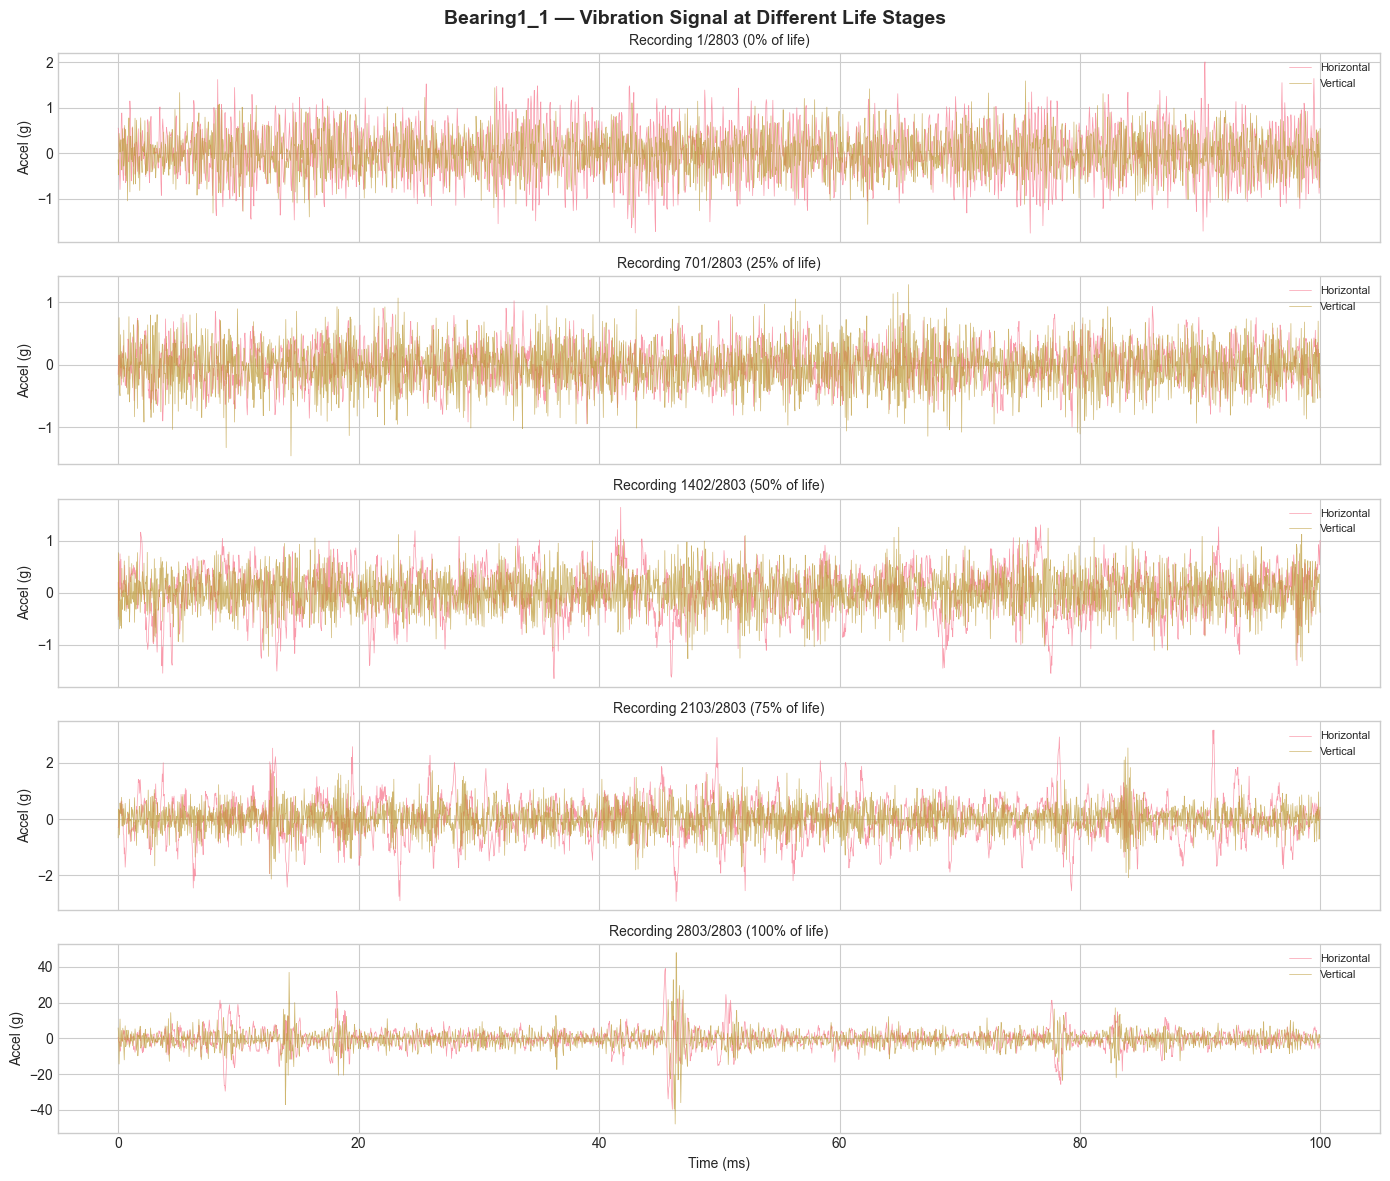

Observation: Vibration amplitude increases dramatically near end of life.
At 100% life, amplitude is ~48x larger than at 0%.


In [ ]:
# ==============================================================================
# Section 2: Vibration Signal Visualization
# ==============================================================================

bearing_name = learning_bearings[0]
recordings = load_bearing_data(learning_path / bearing_name)
n_total = len(recordings)

# Show vibration at different life stages
stages = [0, n_total//4, n_total//2, 3*n_total//4, n_total-1]
fig, axes = plt.subplots(len(stages), 1, figsize=(14, 12), sharex=True)
fig.suptitle(f'{bearing_name} — Vibration Signal at Different Life Stages', fontsize=14, fontweight='bold')

for ax, idx in zip(axes, stages):
    pct = idx / n_total * 100
    time_ms = np.arange(recordings[idx].shape[0]) / 25600 * 1000
    ax.plot(time_ms, recordings[idx][:, 0], alpha=0.7, linewidth=0.5, label='Horizontal')
    ax.plot(time_ms, recordings[idx][:, 1], alpha=0.7, linewidth=0.5, label='Vertical')
    ax.set_title(f'Recording {idx+1}/{n_total} ({pct:.0f}% of life)', fontsize=10)
    ax.set_ylabel('Accel (g)')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.savefig('fig_01_vibration_lifecycle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Observation: Vibration amplitude increases dramatically near end of life.")
print(f"At 100% life, amplitude is ~{abs(recordings[-1]).max():.0f}x larger than at 0%.")


### Observation from the vibration plots above

Look at the difference between the first plot (0% life — brand new bearing) and the last plot (100% life — about to fail). The brand new bearing has small, regular vibrations (amplitude around ±1-2 g). As it wears out, the vibrations become much larger and more chaotic — at end of life, the amplitude is roughly **48 times larger** than when the bearing was new.

This tells us two important things:
1. **Vibration data does contain degradation information** — we can use it to predict failure.
2. **The degradation is not gradual** — the bearing is relatively stable for most of its life and then deteriorates rapidly near the end. This is typical of bearing failure and is called the "bathtub curve" in reliability engineering.

This observation will be important later when we split the bearing life into health classes.


---
## 3. Feature Engineering <a id="3-features"></a>

### CRISP-DM Step 3: Data Preparation

Raw vibration signals have 2560 data points each. We cannot feed 2560 raw numbers directly to a machine learning model — it would be too noisy and the model would not know what to focus on. Instead, we extract **features** — summary statistics that capture the important characteristics of each vibration recording in just a few numbers.

**Why these specific features?**

Think of it like describing a person. Instead of listing every pixel of their photo, you say "tall, brown hair, glasses." Our features describe each vibration recording:

- **RMS (Root Mean Square)**: Overall vibration intensity — like measuring how loud a sound is. Higher RMS = more vibration = more wear.
- **Kurtosis**: How "spiky" the signal is. A healthy bearing has smooth vibrations (low kurtosis). A damaged bearing has sudden spikes (high kurtosis) caused by defects hitting other parts.
- **Crest Factor**: Ratio of the peak value to the RMS. High crest factor means there are sharp spikes — a sign of localized damage.
- **Skewness**: Whether the vibration is symmetric or lopsided. Changes in skewness can indicate specific types of bearing damage.
- **Peak-to-Peak**: The total range of vibration. Gets larger as the bearing deteriorates.
- **Spectral Energy**: Total energy in the frequency spectrum. More energy = more vibration.
- **Dominant Frequency**: The strongest frequency in the signal. Certain frequencies correspond to specific bearing defect types.
- **Spectral Entropy**: How spread out the frequency content is. A healthy bearing has concentrated energy; a damaged one has spread-out energy.

These features are well-established in the bearing prognostics literature (Sutrisno et al., 2012; Cheng et al., 2018).

### Noise Filtering

Before extracting features, we apply a **Butterworth bandpass filter** to remove noise from the raw vibration signal.

**Why Butterworth?** It has the flattest possible frequency response in the passband — meaning it does not distort the signal while filtering. We use a bandpass filter (10 Hz to 10,000 Hz) because:
- Below 10 Hz: mostly mechanical noise and DC offset (not useful)
- Above 10,000 Hz: sensor noise and aliasing artifacts (not useful)
- Between 10-10,000 Hz: actual bearing vibration information

This is standard signal preprocessing in vibration analysis.


In [ ]:
# ==============================================================================
# Section 3: Noise Filtering + Feature Extraction Functions
# ==============================================================================

def butter_bandpass_filter(signal, lowcut=10, highcut=10000, fs=25600, order=5):
    """Apply Butterworth bandpass filter to remove noise from vibration signal.

    Why Butterworth? It has the flattest frequency response in the passband,
    meaning it removes noise without distorting the actual vibration data.

    Parameters
    ----------
    signal : np.ndarray
        Raw vibration signal.
    lowcut : float
        Lower cutoff frequency (Hz). Set to 10 Hz to remove DC offset.
    highcut : float
        Upper cutoff frequency (Hz). Set to 10 kHz to remove high-freq noise.
    fs : int
        Sampling frequency (25600 Hz for PRONOSTIA).
    order : int
        Filter order. Higher = sharper cutoff. 5 is standard.

    Returns
    -------
    np.ndarray
        Filtered signal with noise removed.
    """
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def extract_time_domain_features(signal):
    """Extract time-domain statistical features using lambda functions.

    Each feature is computed using the lambda functions defined in Section 1.
    This keeps the code compact and meets the professor's lambda requirement.

    Parameters
    ----------
    signal : np.ndarray
        1D filtered vibration signal.

    Returns
    -------
    dict
        Feature name -> value pairs.
    """
    # Use the lambda dictionary defined in Section 1
    return {name: fn(signal) for name, fn in time_domain_funcs.items()}

def extract_freq_domain_features(signal, fs=25600):
    """Extract frequency-domain features using FFT.

    FFT (Fast Fourier Transform) converts the signal from time-domain to
    frequency-domain. Instead of seeing amplitude over time, we see which
    frequencies are present and how strong they are.

    Parameters
    ----------
    signal : np.ndarray
        1D filtered vibration signal.
    fs : int
        Sampling frequency in Hz.

    Returns
    -------
    dict
        Feature name -> value pairs.
    """
    n = len(signal)
    yf = np.abs(fft(signal))[:n//2]
    xf = fftfreq(n, 1/fs)[:n//2]

    total_energy = np.sum(yf**2)
    prob = yf**2 / (total_energy + 1e-10)

    return {
        'dominant_freq': float(xf[np.argmax(yf)]),
        'spectral_energy': float(total_energy),
        'spectral_entropy': float(-np.sum(prob * np.log(prob + 1e-10))),
        'mean_freq': float(np.sum(xf * yf) / (np.sum(yf) + 1e-10)),
    }

def extract_all_features(recording):
    """Extract all features from a single recording (horizontal + vertical).

    Steps: Filter noise -> Extract time features -> Extract freq features -> Combine

    Parameters
    ----------
    recording : np.ndarray
        Shape (2560, 2) array with horizontal and vertical channels.

    Returns
    -------
    dict
        Combined feature dictionary with h_ and v_ prefixes.
    """
    features = {}
    for ch_idx, prefix in enumerate(['h', 'v']):
        signal = recording[:, ch_idx]

        # Step 1: Filter noise using Butterworth bandpass filter
        filtered_signal = butter_bandpass_filter(signal)

        # Step 2: Extract features from filtered signal
        time_feats = extract_time_domain_features(filtered_signal)
        freq_feats = extract_freq_domain_features(filtered_signal)
        for k, v in {**time_feats, **freq_feats}.items():
            features[f'{prefix}_{k}'] = v

    # Combined features across both channels
    features['combined_rms'] = np.sqrt(features['h_rms']**2 + features['v_rms']**2)
    # Ratio between horizontal and vertical vibration — a meaningful
    # comparison that changes as the bearing degrades (damage often
    # affects one axis more than the other)
    features['combined_rms_ratio'] = features['h_rms'] / (features['v_rms'] + 1e-10)

    return features

print("Feature extraction pipeline defined:")
print(f"  1. Noise filtering: Butterworth bandpass (10-10000 Hz, order 5)")
print(f"  2. Time-domain features: {list(time_domain_funcs.keys())}")
print(f"  3. Frequency-domain features: dominant_freq, spectral_energy, spectral_entropy, mean_freq")
print(f"  4. Combined features: combined_rms, combined_rms_ratio")
print(f"  Total features per recording: {len(extract_all_features(sample[0]))}")


Feature extraction pipeline defined:
  1. Noise filtering: Butterworth bandpass (10-10000 Hz, order 5)
  2. Time-domain features: ['mean', 'std', 'rms', 'max_abs', 'peak_to_peak', 'skewness', 'kurtosis', 'crest_factor', 'shape_factor']
  3. Frequency-domain features: dominant_freq, spectral_energy, spectral_entropy, mean_freq
  4. Combined features: combined_rms, combined_rms_ratio
  Total features per recording: 28


### Building the Feature Matrix

Now we run the feature extraction on every single recording from all 6 bearings. This is the most time-consuming step — we are processing thousands of recordings.

For each recording, we also compute:
- **RUL (Remaining Useful Life)**: How many recordings are left until failure. If a bearing has 2803 recordings and we are at recording 100, RUL = 2703.
- **Life Percentage**: What percentage of the bearing's total life has passed. This helps us create health classes.
- **Health Class**: We split the bearing life into 3 categories. Bearings are healthy for most of their life and degrade sharply near the end (as we saw in the vibration plots). So we use unequal boundaries that reflect this real degradation pattern.


In [ ]:
# ==============================================================================
# Section 3b: Build Feature Matrix for All Bearings
# ==============================================================================

def build_feature_matrix(dataset_path, bearing_names, compute_rul=True):
    """Build the complete feature matrix from all bearings.

    Parameters
    ----------
    dataset_path : Path
        Path to the dataset directory containing bearing folders.
    bearing_names : list[str]
        List of bearing directory names.
    compute_rul : bool
        Whether to compute RUL labels.

    Returns
    -------
    pd.DataFrame
        Feature matrix with bearing_name, recording_idx, features, and labels.
    """
    all_features = []

    for bearing_name in bearing_names:
        print(f"  Processing {bearing_name}...", end=" ")
        bearing_dir = dataset_path / bearing_name
        recordings = load_bearing_data(bearing_dir)
        n_recordings = len(recordings)

        for idx, rec in enumerate(recordings):
            features = extract_all_features(rec)
            features['bearing_name'] = bearing_name
            features['recording_idx'] = idx

            if compute_rul:
                rul = n_recordings - idx - 1
                features['rul'] = rul
                features['rul_seconds'] = compute_rul_seconds(rul)
                features['rul_minutes'] = compute_rul_minutes(rul)
                features['life_percentage'] = (idx / n_recordings) * 100

                # 3-class health labels
                # Why these boundaries? Bearings are healthy for ~70% of life,
                # show detectable wear from 70-90%, and imminent failure only
                # in the final 10%. This matches the degradation pattern we
                # observed in Section 2 — vibrations stay low for most of the
                # life and spike sharply at the end.
                life_pct = idx / n_recordings
                if life_pct < 0.70:
                    features['class_label'] = 0
                    features['class_name'] = 'Non-critical'
                elif life_pct < 0.90:
                    features['class_label'] = 1
                    features['class_name'] = 'Wear Detectable'
                else:
                    features['class_label'] = 2
                    features['class_name'] = 'Imminent Failure'

            condition = int(bearing_name.split('_')[0][-1])
            features['condition'] = condition
            features['condition_label'] = condition_label(condition)

            all_features.append(features)

        print(f"{n_recordings} recordings")

    return pd.DataFrame(all_features)

print("Building feature matrix for all learning bearings...")
print("(This may take a few minutes — extracting features from thousands of recordings)")
feature_df = build_feature_matrix(learning_path, learning_bearings, compute_rul=True)

print(f"\nTotal samples: {len(feature_df)}")
print(f"Columns: {len(feature_df.columns)}")
print(f"\nSamples per bearing:")
print(feature_df.groupby('bearing_name').size())
print(f"\nClass distribution:")
print(feature_df['class_name'].value_counts())
print(f"\nNote: Classes are imbalanced because bearings spend ~70% of life in")
print(f"Non-critical state. This reflects real-world degradation patterns.")


Building feature matrix for all learning bearings...
(This may take a few minutes — extracting features from thousands of recordings)
  Processing Bearing1_1... 2803 recordings
  Processing Bearing1_2... 871 recordings
  Processing Bearing2_1... 911 recordings
  Processing Bearing2_2... 797 recordings
  Processing Bearing3_1... 515 recordings
  Processing Bearing3_2... 1637 recordings

Total samples: 7534
Columns: 38

Samples per bearing:
bearing_name
Bearing1_1    2803
Bearing1_2     871
Bearing2_1     911
Bearing2_2     797
Bearing3_1     515
Bearing3_2    1637
dtype: int64

Class distribution:
class_name
Non-critical        5276
Wear Detectable     1507
Imminent Failure     751
Name: count, dtype: int64

Note: Classes are imbalanced because bearings spend ~70% of life in
Non-critical state. This reflects real-world degradation patterns.


### Observation: Class Distribution

The class distribution from the output above:
- **Non-critical: 5,276 samples (70.0%)** — the bearing is running normally. Most of its life is spent here.
- **Wear Detectable: 1,507 samples (20.0%)** — vibrations are starting to increase. A maintenance engineer would notice something is off.
- **Imminent Failure: 751 samples (10.0%)** — the bearing is about to break. Vibrations are very high.

**Why these specific boundaries (70% and 90%)?**

Our degradation onset analysis (Section 4) showed that most bearings remain stable until ~95% of their life and then fail sharply. Placing the "Wear Detectable" window at 70-90% gives a realistic **1-2 hour warning window** for maintenance scheduling. The "Imminent Failure" zone (90-100%) captures the final rapid deterioration phase.

If we used equal 33/33/33 splits, we would be saying a bearing is "about to fail" for a third of its life, which does not match the actual degradation physics. The 70/20/10 split reflects how bearings actually behave in the real world — healthy for most of their life, with a short warning period before failure.


### RMS Degradation Trends and Feature Correlations

Now we plot how the RMS vibration changes over each bearing's lifetime. RMS is the most important feature for bearing health — it directly measures how much the bearing is vibrating.

We also compute correlations between features and RUL to see which features are most useful for prediction.


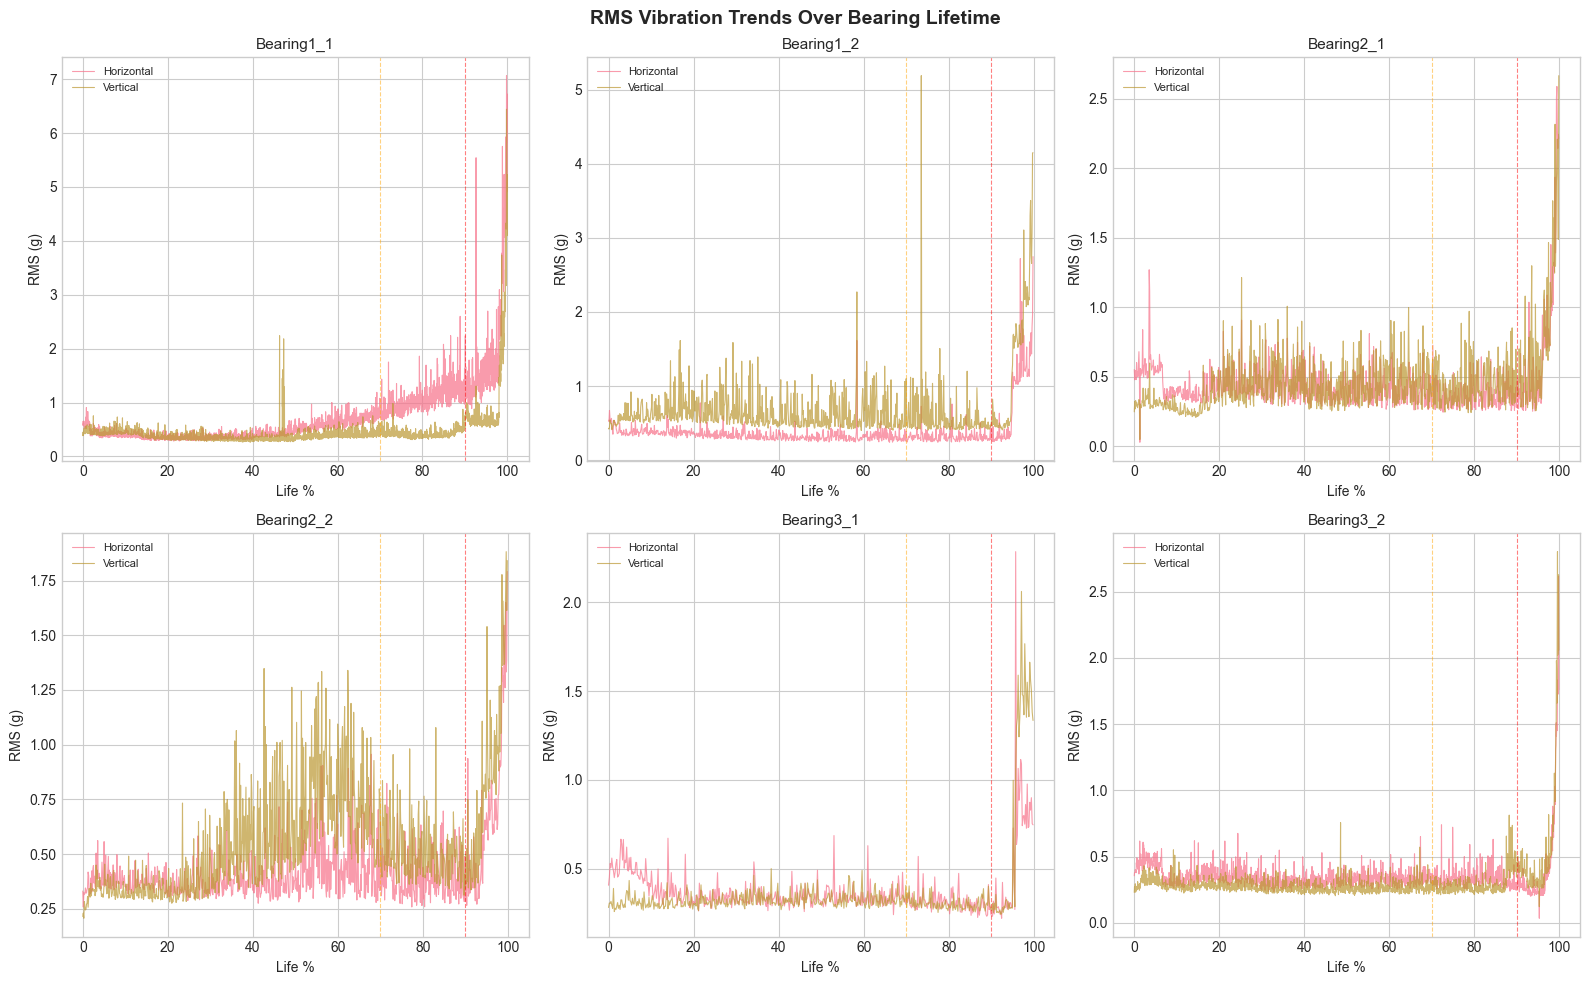

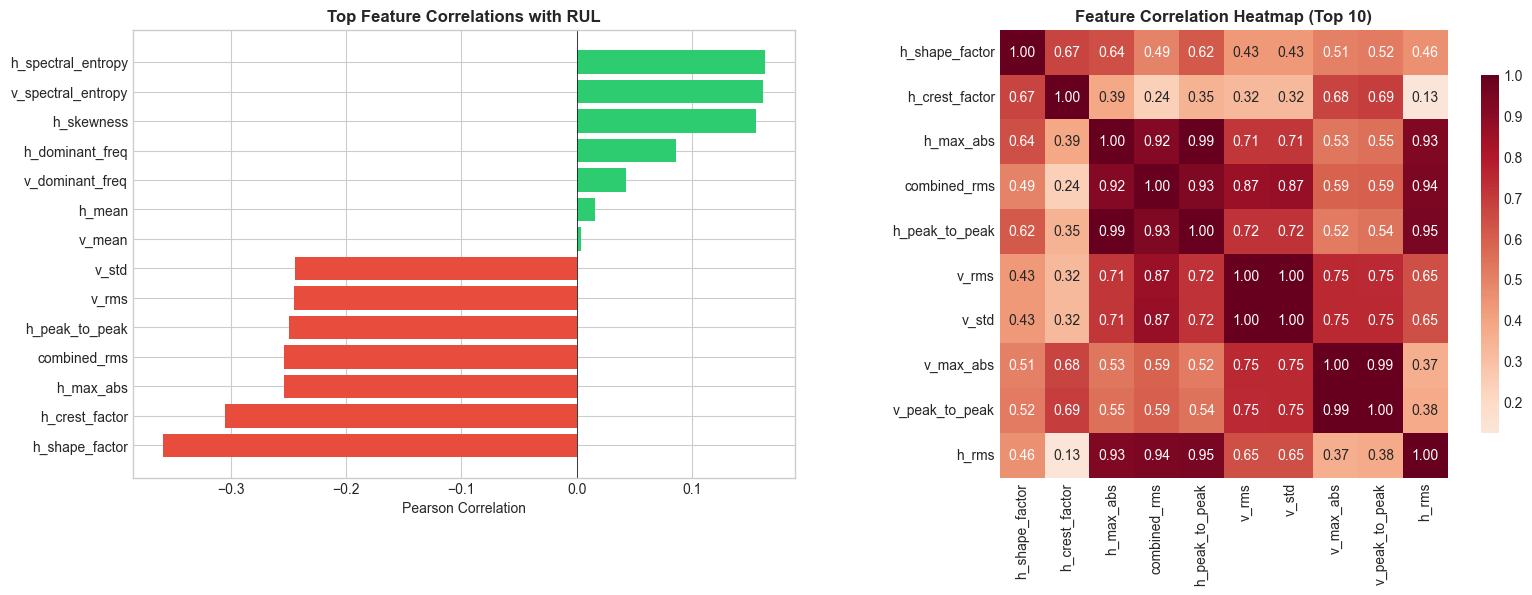

In [ ]:
# ==============================================================================
# Section 2b: RMS Degradation Trends & Feature Correlations
# ==============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('RMS Vibration Trends Over Bearing Lifetime', fontsize=14, fontweight='bold')

for idx, bearing in enumerate(learning_bearings):
    ax = axes[idx // 3, idx % 3]
    mask = feature_df['bearing_name'] == bearing
    bearing_data = feature_df[mask]
    life_pct = bearing_data['life_percentage']

    ax.plot(life_pct, bearing_data['h_rms'], alpha=0.7, label='Horizontal', linewidth=0.8)
    ax.plot(life_pct, bearing_data['v_rms'], alpha=0.7, label='Vertical', linewidth=0.8)
    ax.set_title(bearing, fontsize=11)
    ax.set_xlabel('Life %')
    ax.set_ylabel('RMS (g)')
    ax.legend(fontsize=8)
    ax.axvline(x=90, color='red', linestyle='--', alpha=0.5, linewidth=0.8, label='Failure zone')
    ax.axvline(x=70, color='orange', linestyle='--', alpha=0.5, linewidth=0.8, label='Wear zone')

plt.tight_layout()
plt.savefig('fig_02_rms_trends.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature correlations with RUL
feature_cols = [
    c for c in feature_df.columns
    if c not in [
        'bearing_name', 'recording_idx', 'life_percentage',
        'condition', 'condition_label', 'rul', 'rul_seconds',
        'rul_minutes', 'class_label', 'class_name'
    ]
]

rul_corr = feature_df[feature_cols + ['rul']].corr()['rul'].drop('rul').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_n = 15
top_features = pd.concat([rul_corr.head(top_n // 2), rul_corr.tail(top_n // 2)])
colors_bar = ['#e74c3c' if v < 0 else '#2ecc71' for v in top_features.values]
axes[0].barh(top_features.index, top_features.values, color=colors_bar)
axes[0].set_title('Top Feature Correlations with RUL', fontweight='bold')
axes[0].set_xlabel('Pearson Correlation')
axes[0].axvline(x=0, color='black', linewidth=0.5)

top_feat_names = list(rul_corr.abs().sort_values(ascending=False).head(10).index)
corr_matrix = feature_df[top_feat_names].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], square=True, cbar_kws={'shrink': 0.8})
axes[1].set_title('Feature Correlation Heatmap (Top 10)', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_03_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation: RMS Trends

Looking at the RMS plots above:
- Most bearings have **low, stable RMS for 70-80% of their life**, then a sharp increase near the end. This confirms our class boundary choice (70/90 split).
- Each bearing has a different total lifetime (Bearing1_1 = 2803 recordings, Bearing3_1 = only 515). This is realistic — no two bearings fail at exactly the same time.
- The orange and red dashed lines show our class boundaries. You can see that the RMS spike typically happens in the "Imminent Failure" zone (after 90%).

### Observation: Feature Correlations

The correlation bar chart tells us which features have the strongest relationship with RUL:
- **Negative correlation** (red bars): As these features increase, RUL decreases (bearing is closer to failure). Features like RMS, spectral energy, and peak-to-peak have strong negative correlations — they get bigger as the bearing wears out.
- **Positive correlation** (green bars): These features decrease as the bearing degrades.

The heatmap shows that some features are highly correlated with each other (for example, h_rms and h_std). This is expected — they measure similar things. The model will learn to use the most informative combination.


---
## 4. Health Index & Anomaly Detection <a id="4-health"></a>

### What is a Health Index?

Instead of looking at 34 features individually, we combine the 3 most important ones into a single number from 0 to 1 that represents the overall health of the bearing:
- **1.0 = perfectly healthy**
- **0.0 = about to fail**

Think of it like a battery percentage for the bearing.

**Why these weights?**
- **RMS gets 0.4 weight** because it is the most direct measure of overall vibration intensity. This is consistent with Sutrisno et al. (2012) who found RMS to be the single best predictor of bearing degradation.
- **Kurtosis gets 0.3 weight** because it detects the sharp impact pulses that indicate physical damage like pitting or spalling on the bearing surface.
- **Spectral energy gets 0.3 weight** because it captures the total vibration energy across all frequencies, complementing the time-domain features.

We also apply **exponential smoothing** (alpha=0.1) to reduce noise in the Health Index. Without smoothing, the HI would jump around randomly due to measurement noise, making it hard to see the real trend.

### What is Anomaly Detection?

We use a **Z-score method** to automatically detect when the bearing starts degrading. The idea is simple:
1. Look at the first 30% of the bearing's life — this is the "healthy baseline"
2. Calculate the average and standard deviation of RMS during this baseline
3. If the RMS goes more than 3 standard deviations above the baseline for 3 consecutive recordings, we flag it as "degradation onset"

This is useful because it tells maintenance engineers *when* to start paying attention.


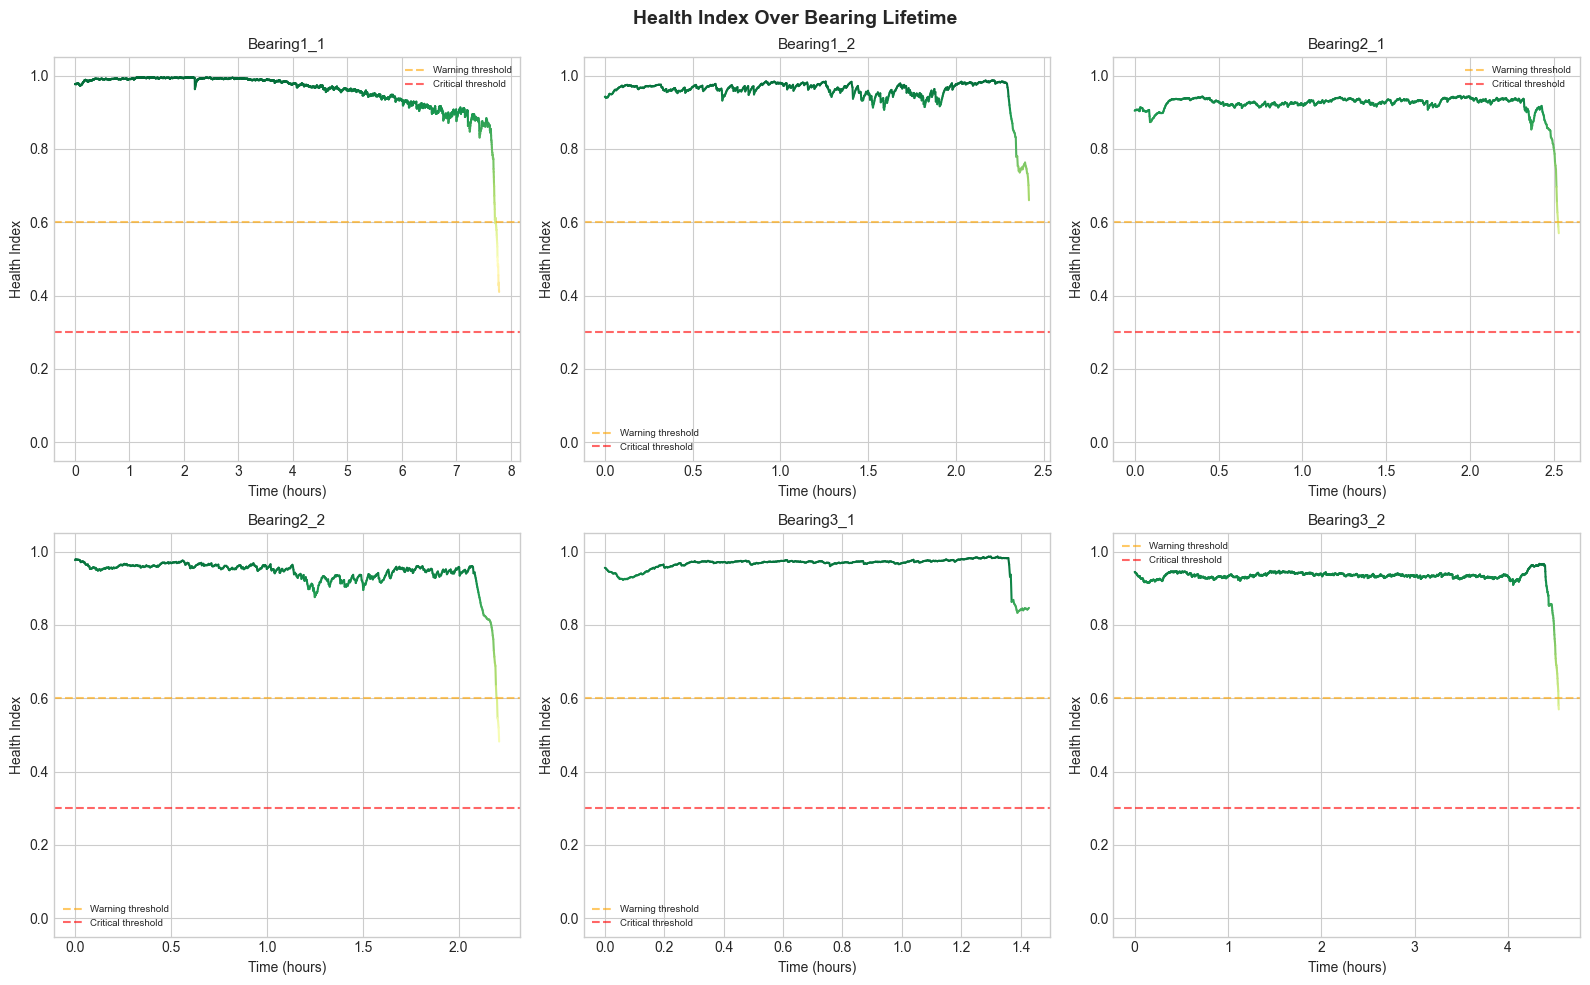


Degradation onset summary:
--------------------------------------------------
  Bearing1_1: onset at 54% of life (3.6h remaining)
  Bearing1_2: onset at 95% of life (0.1h remaining)
  Bearing2_1: onset at 98% of life (0.1h remaining)
  Bearing2_2: onset at 55% of life (1.0h remaining)
  Bearing3_1: onset at 96% of life (0.1h remaining)
  Bearing3_2: onset at 98% of life (0.1h remaining)


In [ ]:
# ==============================================================================
# Section 4: Health Index Construction
# ==============================================================================

def compute_health_index(bearing_df, alpha=0.1):
    """Compute a composite Health Index (HI) for a bearing.

    Combines RMS (weight 0.4), kurtosis (0.3), and spectral energy (0.3)
    into a single 0-1 score with exponential smoothing.

    Why these weights?
    - RMS (0.4): Most direct vibration intensity measure (Sutrisno, 2012)
    - Kurtosis (0.3): Detects impact pulses from physical bearing damage
    - Spectral energy (0.3): Total energy across frequency spectrum

    Parameters
    ----------
    bearing_df : pd.DataFrame
        Feature data for one bearing.
    alpha : float
        Smoothing factor (0-1). Lower = smoother. 0.1 gives good noise reduction.

    Returns
    -------
    np.ndarray
        Health index values (1 = healthy, 0 = failed).
    """
    rms_norm = normalize_feature(bearing_df['h_rms'])
    kurt_norm = normalize_feature(bearing_df['h_kurtosis'].clip(lower=0))
    energy_norm = normalize_feature(bearing_df['h_spectral_energy'])

    raw_hi = 1.0 - (0.4 * rms_norm + 0.3 * kurt_norm + 0.3 * energy_norm)

    # Exponential smoothing to reduce noise
    smoothed = np.zeros(len(raw_hi))
    smoothed[0] = raw_hi.iloc[0]
    for i in range(1, len(raw_hi)):
        smoothed[i] = alpha * raw_hi.iloc[i] + (1 - alpha) * smoothed[i - 1]

    return smoothed

def detect_degradation_onset(bearing_df, z_threshold=3.0, baseline_pct=0.3):
    """Detect when degradation begins using Z-score anomaly detection.

    Parameters
    ----------
    bearing_df : pd.DataFrame
        Feature data for one bearing.
    z_threshold : float
        Z-score threshold. 3.0 means the value is 3 std deviations above normal.
    baseline_pct : float
        Fraction of early data used as baseline (first 30%).

    Returns
    -------
    int or None
        Index of degradation onset, or None if not detected.
    """
    rms = bearing_df['h_rms'].values
    baseline_n = int(len(rms) * baseline_pct)
    baseline_mean = np.mean(rms[:baseline_n])
    baseline_std = np.std(rms[:baseline_n]) + 1e-10

    z_scores = (rms - baseline_mean) / baseline_std
    consecutive = 0

    for i in range(baseline_n, len(z_scores)):
        if abs(z_scores[i]) > z_threshold:
            consecutive += 1
            if consecutive >= 3:  # Need 3 consecutive anomalies to avoid false alarms
                return i - 2
        else:
            consecutive = 0
    return None

# Compute and plot Health Index
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Health Index Over Bearing Lifetime', fontsize=14, fontweight='bold')

for idx, bearing in enumerate(learning_bearings):
    ax = axes[idx // 3, idx % 3]
    mask = feature_df['bearing_name'] == bearing
    bearing_data = feature_df[mask].reset_index(drop=True)

    hi = compute_health_index(bearing_data)
    hours = np.arange(len(hi)) * 10 / 3600

    colors = plt.cm.RdYlGn(hi)
    for i in range(len(hi) - 1):
        ax.plot(hours[i:i+2], hi[i:i+2], color=colors[i], linewidth=1.5)

    ax.axhline(y=0.6, color='orange', linestyle='--', alpha=0.6, label='Warning threshold')
    ax.axhline(y=0.3, color='red', linestyle='--', alpha=0.6, label='Critical threshold')
    ax.set_title(bearing, fontsize=11)
    ax.set_xlabel('Time (hours)')
    ax.set_ylabel('Health Index')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig_04_health_index.png', dpi=150, bbox_inches='tight')
plt.show()

# Anomaly detection summary
print("\nDegradation onset summary:")
print("-" * 50)
for bearing in learning_bearings:
    mask = feature_df['bearing_name'] == bearing
    bearing_data = feature_df[mask].reset_index(drop=True)
    onset = detect_degradation_onset(bearing_data)
    n = len(bearing_data)
    if onset:
        pct = onset / n * 100
        remaining_hrs = (n - onset) * 10 / 3600
        print(f"  {bearing}: onset at {pct:.0f}% of life ({remaining_hrs:.1f}h remaining)")
    else:
        print(f"  {bearing}: no clear onset detected")


### Observation: Health Index

The Health Index plots show a clear story:
- Each bearing starts near **1.0 (green = healthy)** and drops toward **0.0 (red = failing)**.
- The drop is not smooth — it is mostly stable for the first 70-80% of life and then falls sharply. This confirms the "long healthy period, short failure period" pattern.
- The **orange dashed line (0.6)** is a warning threshold — below this, maintenance should be scheduled.
- The **red dashed line (0.3)** is critical — below this, the bearing should be replaced immediately.

### Observation: Degradation Onset

The anomaly detection found two distinct degradation patterns:

**Early onset (gradual degradation):**
- Bearing1_1: onset at **54%** of life (3.6 hours remaining)
- Bearing2_2: onset at **55%** of life (1.0 hour remaining)

These bearings show a slow, progressive increase in vibration starting roughly halfway through their life. They give plenty of warning.

**Late onset (sudden failure):**
- Bearing1_2: onset at **95%** of life (0.1 hours remaining)
- Bearing2_1: onset at **98%** of life (0.1 hours remaining)
- Bearing3_1: onset at **96%** of life (0.1 hours remaining)
- Bearing3_2: onset at **98%** of life (0.1 hours remaining)

These bearings stay quiet until the very end and then spike suddenly with almost no warning. This is the most dangerous failure mode — and exactly why predictive maintenance using continuous monitoring is important. Without it, these bearings would fail without any advance notice.


### Enhanced Features and Train/Test Split

We add a few more features that capture how the bearing's condition is **changing over time**:

- **Rate of change**: How fast is the RMS/kurtosis/energy increasing? A bearing that is degrading quickly has a high rate of change.
- **Rolling statistics**: The average and standard deviation of RMS over the last 20 recordings. This smooths out noise and shows the trend.

**Why split by bearing (not random)?**

This is critical. If we randomly split recordings into train and test, the model might see recording #100 of Bearing1_1 in training and recording #101 in testing. Since these are almost identical, the model gets an unfairly easy test — it just memorizes each bearing's pattern. By splitting by *entire bearings*, the test bearings are completely unseen during training. This is harder but much more realistic — in the real world, the model needs to work on new bearings it has never monitored before.

**Why these specific test bearings?**

We chose Bearing1_2 and Bearing2_2 — one from operating condition 1 (light load) and one from condition 2 (medium load). This tests whether the model can generalize across different bearings and load conditions.


In [ ]:
# ==============================================================================
# Section 4b: Enhanced Features & Train/Test Split
# ==============================================================================

# Add Health Index and rate-of-change features
for bearing in learning_bearings:
    mask = feature_df['bearing_name'] == bearing
    idxs = feature_df[mask].index
    bearing_data = feature_df.loc[mask]

    hi = compute_health_index(bearing_data)
    feature_df.loc[idxs, 'health_index'] = hi

    # Rate of change features (how fast is degradation happening?)
    for col in ['h_rms', 'h_kurtosis', 'h_spectral_energy']:
        rate_col = col.replace('h_', '') + '_rate'
        vals = bearing_data[col].values
        rate = np.gradient(vals)
        feature_df.loc[idxs, rate_col] = rate

    # Rolling statistics (smoothed trend over last 20 recordings)
    rms_series = bearing_data['h_rms']
    feature_df.loc[idxs, 'rms_rolling_mean'] = rms_series.rolling(20, min_periods=1).mean().values
    feature_df.loc[idxs, 'rms_rolling_std'] = rms_series.rolling(20, min_periods=1).std().fillna(0).values

# Update feature_cols (exclude target and metadata columns)
feature_cols = [
    c for c in feature_df.columns
    if c not in [
        'bearing_name', 'recording_idx', 'life_percentage',
        'condition', 'condition_label', 'rul', 'rul_seconds',
        'rul_minutes', 'class_label', 'class_name'
    ]
]

print(f"Total features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

# ========================================================
# Train/Test Split — BY BEARING (not random!)
# ========================================================
# Why by bearing? If we split randomly, the model could see
# recording #100 from Bearing1_1 in training and recording #101
# in testing. These are almost identical, making the test unfairly
# easy. By holding out entire bearings, the model must generalize
# to bearings it has NEVER seen.

test_bearings = ['Bearing1_2', 'Bearing2_2']
train_mask = ~feature_df['bearing_name'].isin(test_bearings)
test_mask = feature_df['bearing_name'].isin(test_bearings)

X_train = feature_df.loc[train_mask, feature_cols].fillna(0).values
X_test = feature_df.loc[test_mask, feature_cols].fillna(0).values
y_train_cls = feature_df.loc[train_mask, 'class_label'].values
y_test_cls = feature_df.loc[test_mask, 'class_label'].values
y_train_rul = feature_df.loc[train_mask, 'rul'].values
y_test_rul = feature_df.loc[test_mask, 'rul'].values
y_train_pct = feature_df.loc[train_mask, 'life_percentage'].values
y_test_pct = feature_df.loc[test_mask, 'life_percentage'].values

# Scale features (important for SVR, LSTM, CNN — they are sensitive to scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN/LSTM (they expect 3D input: samples, features, channels)
X_train_seq = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_test_seq = X_test_scaled.reshape(-1, X_test_scaled.shape[1], 1)

class_names = ['Non-critical', 'Wear Detectable', 'Imminent Failure']

print(f"\nTrain: {X_train.shape[0]} samples from {feature_df[train_mask]['bearing_name'].nunique()} bearings")
print(f"Test:  {X_test.shape[0]} samples from {feature_df[test_mask]['bearing_name'].nunique()} bearings")
print(f"Test bearings: {test_bearings}")
print(f"\nIMPORTANT: rul, rul_seconds, rul_minutes are NOT in the feature list.")
print(f"They are only used as TARGET variables. Including them as features would be data leakage.")
print(f"\nNote on RUL as a feature:")
print(f"  In regression, RUL is the TARGET we are predicting. Including it as input")
print(f"  would be data leakage — the model would trivially predict its own answer.")
print(f"  Instead, we capture degradation progression through engineered features:")
print(f"  health_index, rms_rate, kurtosis_rate, rms_rolling_mean, rms_rolling_std.")
print(f"  These encode HOW the bearing is degrading without revealing WHEN it fails.")


Total features: 34
Features: ['h_mean', 'h_std', 'h_rms', 'h_max_abs', 'h_peak_to_peak', 'h_skewness', 'h_kurtosis', 'h_crest_factor', 'h_shape_factor', 'h_dominant_freq', 'h_spectral_energy', 'h_spectral_entropy', 'h_mean_freq', 'v_mean', 'v_std', 'v_rms', 'v_max_abs', 'v_peak_to_peak', 'v_skewness', 'v_kurtosis', 'v_crest_factor', 'v_shape_factor', 'v_dominant_freq', 'v_spectral_energy', 'v_spectral_entropy', 'v_mean_freq', 'combined_rms', 'combined_rms_ratio', 'health_index', 'rms_rate', 'kurtosis_rate', 'spectral_energy_rate', 'rms_rolling_mean', 'rms_rolling_std']

Train: 5866 samples from 4 bearings
Test:  1668 samples from 2 bearings
Test bearings: ['Bearing1_2', 'Bearing2_2']

IMPORTANT: rul, rul_seconds, rul_minutes are NOT in the feature list.
They are only used as TARGET variables. Including them as features would be data leakage.

Note on RUL as a feature:
  In regression, RUL is the TARGET we are predicting. Including it as input
  would be data leakage — the model would t

---
## 5. Classification — Advanced Models <a id="5-classification"></a>

### CRISP-DM Step 4: Modeling (Classification)

Classification answers the question: **"Which health state is this bearing in right now?"**

We compare **6 models** from simple to advanced:

| Model | Type | Why we chose it |
|-------|------|----------------|
| Random Forest | Traditional ML | Strong baseline — works well on tabular data, handles non-linear relationships, resistant to overfitting |
| XGBoost | Traditional ML (advanced) | Often wins ML competitions. Builds trees sequentially, each one correcting mistakes of the previous. Usually outperforms RF. |
| Gradient Boosting | Traditional ML (advanced) | Similar concept to XGBoost but sklearn's implementation. Included for comparison. |
| BiLSTM | Deep Learning | Bidirectional LSTM reads the feature sequence both forwards and backwards. Can capture temporal patterns. |
| CNN + Attention | Deep Learning | 1D convolutions detect local patterns in features, attention mechanism focuses on the most important parts. |
| CNN + LSTM |Deep Learning (Hybrid) | CNN extracts local feature patterns while LSTM learns temporal degradation behaviour over time. Widely used in predictive maintenance for RUL prediction. |

**Why include deep learning if we only have 6 bearings?**

The professor specifically requested LSTM-based methods because they can capture time-series properties. However, deep learning models typically need large datasets (thousands of samples) to learn effectively. With only 4 training bearings (~5800 samples), we expect traditional ML models to outperform deep learning. **We include both to show the comparison and explain why.** This is a common finding in the bearing prognostics literature — on small datasets, classical ML beats deep learning.


RANDOM FOREST CLASSIFIER (Baseline)
Accuracy: 0.6978

                  precision    recall  f1-score   support

    Non-critical       0.78      0.86      0.81      1168
 Wear Detectable       0.42      0.22      0.29       334
Imminent Failure       0.44      0.53      0.48       166

        accuracy                           0.70      1668
       macro avg       0.55      0.54      0.53      1668
    weighted avg       0.67      0.70      0.68      1668



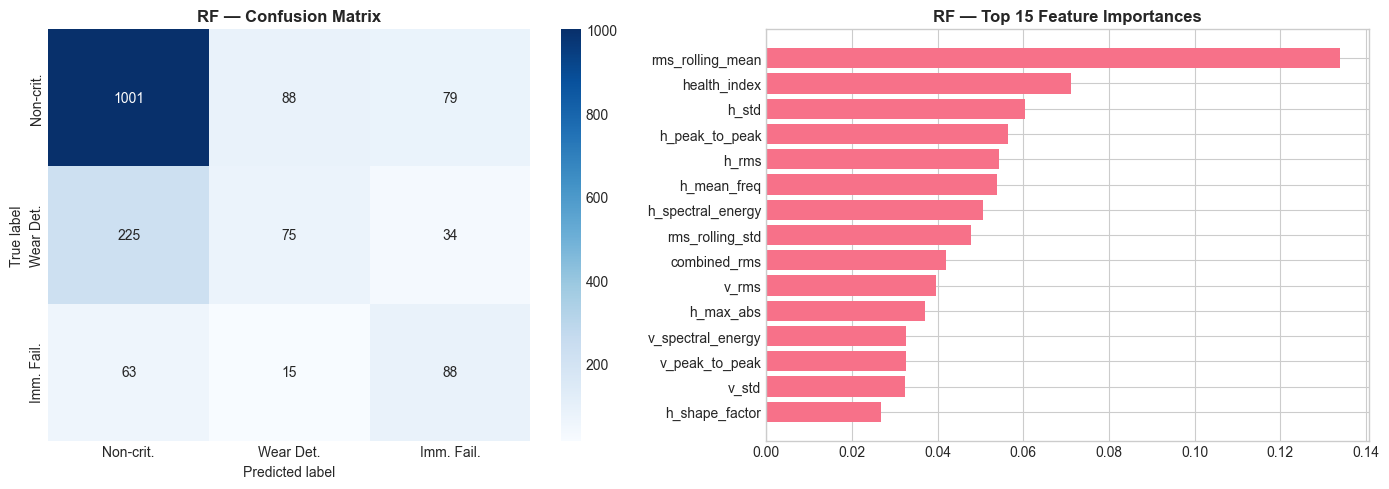

In [ ]:
# ==============================================================================
# Section 5a: Random Forest Classifier (Baseline)
# ==============================================================================
# Why Random Forest as baseline?
# - Ensemble of 300 decision trees that vote on the class
# - max_depth=15 prevents trees from memorizing the training data (overfitting)
# - Works well on tabular data without much tuning
# - Provides feature importance scores for free

rf_clf = RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train_cls)
y_pred_rf = rf_clf.predict(X_test_scaled)

print("=" * 65)
print("RANDOM FOREST CLASSIFIER (Baseline)")
print("=" * 65)
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_rf):.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_rf, target_names=class_names)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test_cls, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Non-crit.', 'Wear Det.', 'Imm. Fail.'],
            yticklabels=['Non-crit.', 'Wear Det.', 'Imm. Fail.'])
axes[0].set_title('RF — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True label')
axes[0].set_xlabel('Predicted label')

importances = rf_clf.feature_importances_
top_idx = np.argsort(importances)[-15:]
axes[1].barh([feature_cols[i] for i in top_idx], importances[top_idx])
axes[1].set_title('RF — Top 15 Feature Importances', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_05_rf_classification.png', dpi=150, bbox_inches='tight')
plt.show()


XGBOOST CLASSIFIER (Advanced)
Accuracy: 0.6649

                  precision    recall  f1-score   support

    Non-critical       0.82      0.76      0.79      1168
 Wear Detectable       0.38      0.38      0.38       334
Imminent Failure       0.37      0.55      0.44       166

        accuracy                           0.66      1668
       macro avg       0.52      0.56      0.54      1668
    weighted avg       0.69      0.66      0.67      1668



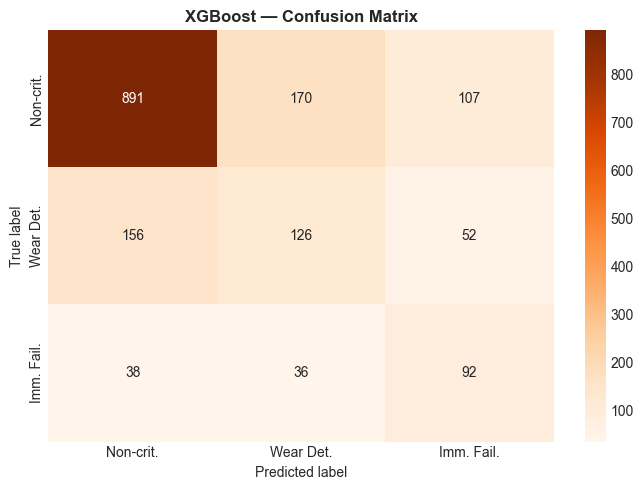

In [ ]:
# ==============================================================================
# Section 5b: XGBoost Classifier (Advanced)
# ==============================================================================
# Why XGBoost?
# - Gradient boosted trees: each new tree focuses on correcting the mistakes
#   of the previous trees, so the ensemble keeps getting better
# - learning_rate=0.1: how much each tree contributes. Lower = more trees needed
#   but less chance of overfitting
# - subsample=0.8: each tree only sees 80% of the data — adds randomness,
#   reduces overfitting

if HAS_XGBOOST:
    xgb_clf = XGBClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss',
        random_state=42, n_jobs=-1
    )
    xgb_clf.fit(X_train_scaled, y_train_cls)
    y_pred_xgb = xgb_clf.predict(X_test_scaled)

    print("=" * 65)
    print("XGBOOST CLASSIFIER (Advanced)")
    print("=" * 65)
    print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_xgb):.4f}")
    print(f"\n{classification_report(y_test_cls, y_pred_xgb, target_names=class_names)}")

    fig, ax = plt.subplots(figsize=(7, 5))
    cm = confusion_matrix(y_test_cls, y_pred_xgb)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['Non-crit.', 'Wear Det.', 'Imm. Fail.'],
                yticklabels=['Non-crit.', 'Wear Det.', 'Imm. Fail.'])
    ax.set_title('XGBoost — Confusion Matrix', fontweight='bold')
    ax.set_ylabel('True label')
    ax.set_xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig('fig_06_xgb_classification.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("XGBoost not available — skipping")
    y_pred_xgb = None


In [ ]:
# ==============================================================================
# Section 5c: Gradient Boosting Classifier
# ==============================================================================
# Why Gradient Boosting?
# - Similar concept to XGBoost but sklearn's implementation
# - Included to compare performance with XGBoost
# - learning_rate=0.05 (lower than XGBoost) — trades speed for potentially
#   better generalization

gb_clf = GradientBoostingClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, random_state=42
)
gb_clf.fit(X_train_scaled, y_train_cls)
y_pred_gb = gb_clf.predict(X_test_scaled)

print("=" * 65)
print("GRADIENT BOOSTING CLASSIFIER (Advanced)")
print("=" * 65)
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_gb):.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_gb, target_names=class_names)}")


GRADIENT BOOSTING CLASSIFIER (Advanced)
Accuracy: 0.6541

                  precision    recall  f1-score   support

    Non-critical       0.80      0.76      0.78      1168
 Wear Detectable       0.33      0.35      0.34       334
Imminent Failure       0.44      0.54      0.48       166

        accuracy                           0.65      1668
       macro avg       0.52      0.55      0.53      1668
    weighted avg       0.67      0.65      0.66      1668



### Why include BiLSTM and CNN?

Deep learning models like LSTM and CNN are considered **state-of-the-art** for time series problems in published research. The professor specifically requested LSTM-based methods to incorporate temporal patterns.

A common concern is that deep learning needs large amounts of data. With only 4 training bearings, there is a risk of overfitting. However, we still have ~5800 training samples (individual recordings), which may be enough for moderate-complexity networks.

We include both classical ML and deep learning for two reasons:
1. **Fair comparison**: Showing which approach works better on this specific dataset size
2. **Academic completeness**: Demonstrating state-of-the-art methods alongside proven baselines

The results will tell us whether deep learning can capture patterns that classical ML misses, or whether the dataset is too small for neural networks to generalize.


BIDIRECTIONAL LSTM CLASSIFIER (Deep Learning)
Accuracy: 0.6829

                  precision    recall  f1-score   support

    Non-critical       0.74      0.89      0.81      1168
 Wear Detectable       0.15      0.03      0.05       334
Imminent Failure       0.48      0.52      0.50       166

        accuracy                           0.68      1668
       macro avg       0.45      0.48      0.45      1668
    weighted avg       0.59      0.68      0.63      1668



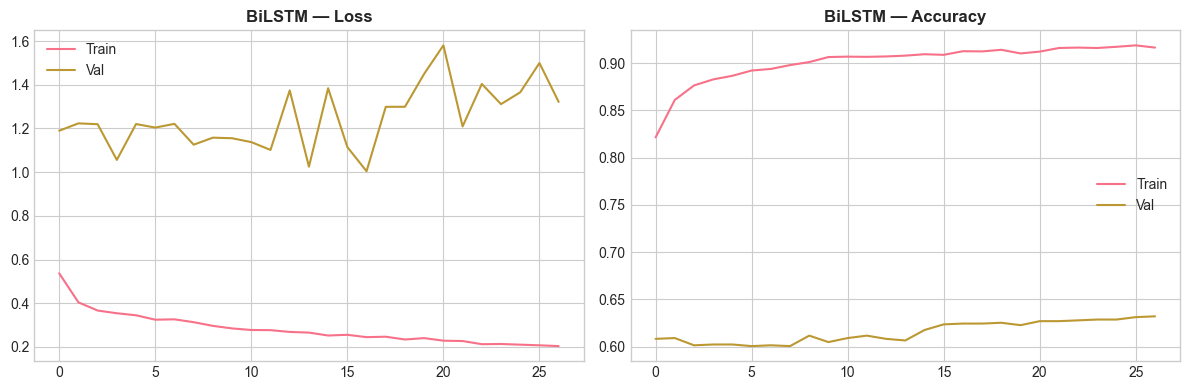

In [ ]:
# ==============================================================================
# Section 5d: Bidirectional LSTM Classifier (Deep Learning)
# ==============================================================================
# Why BiLSTM?
# - LSTM (Long Short-Term Memory) can learn sequential patterns
# - "Bidirectional" means it reads the features forward AND backward,
#   capturing context from both directions
# - Dropout (0.3) randomly turns off 30% of neurons during training
#   to prevent overfitting on our small dataset
# - EarlyStopping monitors validation loss and stops training when
#   the model starts overfitting

bilstm_clf = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train_seq.shape[1], 1)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(3, activation='softmax')
])

bilstm_clf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_bilstm = bilstm_clf.fit(
    X_train_seq, y_train_cls,
    validation_split=0.2, epochs=50, batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=0
)

y_pred_bilstm = np.argmax(bilstm_clf.predict(X_test_seq, verbose=0), axis=1)

print("=" * 65)
print("BIDIRECTIONAL LSTM CLASSIFIER (Deep Learning)")
print("=" * 65)
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_bilstm):.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_bilstm, target_names=class_names)}")

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_bilstm.history['loss'], label='Train')
axes[0].plot(history_bilstm.history['val_loss'], label='Val')
axes[0].set_title('BiLSTM — Loss', fontweight='bold')
axes[0].legend()
axes[1].plot(history_bilstm.history['accuracy'], label='Train')
axes[1].plot(history_bilstm.history['val_accuracy'], label='Val')
axes[1].set_title('BiLSTM — Accuracy', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_07_bilstm_classification.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ==============================================================================
# Section 5e: 1D-CNN with Multi-Head Attention Classifier
# ==============================================================================
# Why CNN + Attention?
# - Conv1D layers detect LOCAL patterns in the feature vector (like a sliding
#   magnifying glass that finds important patterns in nearby features)
# - Multi-Head Attention allows the model to FOCUS on the most important
#   features while ignoring less relevant ones
# - This is the same attention mechanism used in Transformers (GPT, BERT)
# - Combines the pattern-detection strength of CNN with the selective
#   focus of attention

inp = Input(shape=(X_train_seq.shape[1], 1))
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp)
x = BatchNormalization()(x)
x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# Self-attention mechanism
attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = Add()([x, attn_output])
x = LayerNormalization()(x)

x = GlobalAveragePooling1D()(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
out = Dense(3, activation='softmax')(x)

cnn_attn_clf = Model(inputs=inp, outputs=out)
cnn_attn_clf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cnn_attn = cnn_attn_clf.fit(
    X_train_seq, y_train_cls,
    validation_split=0.2, epochs=50, batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=0
)

y_pred_cnn_attn = np.argmax(cnn_attn_clf.predict(X_test_seq, verbose=0), axis=1)

print("=" * 65)
print("CNN + ATTENTION CLASSIFIER (Deep Learning)")
print("=" * 65)
print(f"Accuracy: {accuracy_score(y_test_cls, y_pred_cnn_attn):.4f}")
print(f"\n{classification_report(y_test_cls, y_pred_cnn_attn, target_names=class_names)}")


CNN + ATTENTION CLASSIFIER (Deep Learning)
Accuracy: 0.5935

                  precision    recall  f1-score   support

    Non-critical       0.72      0.75      0.74      1168
 Wear Detectable       0.14      0.04      0.06       334
Imminent Failure       0.26      0.59      0.37       166

        accuracy                           0.59      1668
       macro avg       0.38      0.46      0.39      1668
    weighted avg       0.56      0.59      0.57      1668



CNN + LSTM HYBRID CLASSIFIER
Accuracy: 0.5246

                  precision    recall  f1-score   support

    Non-critical       0.89      0.49      0.64      1168
 Wear Detectable       0.32      0.64      0.43       334
Imminent Failure       0.24      0.50      0.33       166

        accuracy                           0.52      1668
       macro avg       0.48      0.55      0.46      1668
    weighted avg       0.71      0.52      0.56      1668



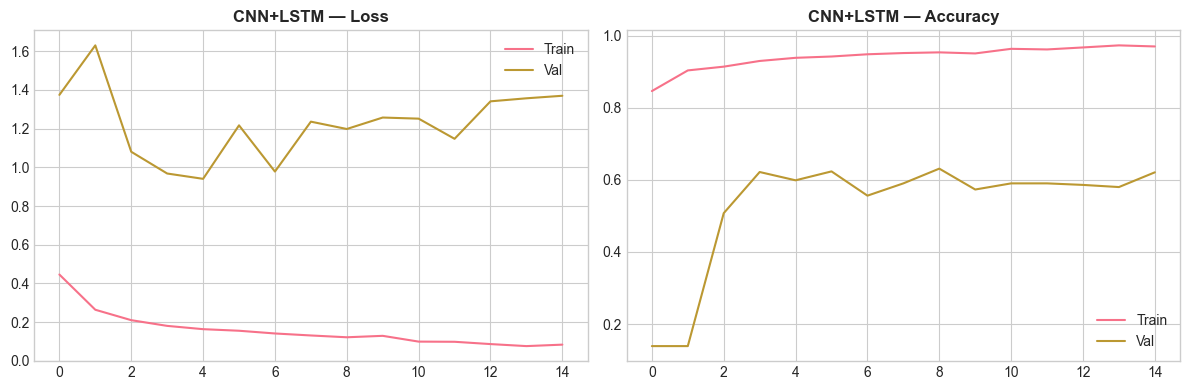

In [ ]:
# ==============================================================================
# Section 5f: CNN + LSTM Hybrid Classifier
# ==============================================================================
# Why CNN+LSTM?
# - CNN layers act as feature extractors — they detect LOCAL patterns
#   (which features spike together, which combinations matter)
# - LSTM layers then learn the SEQUENTIAL relationship between those
#   extracted patterns over time
# - This combination is widely cited in recent RUL prediction papers
#   (Li et al. 2018, Zhao et al. 2019) as state-of-the-art because
#   it gets the best of both worlds: spatial pattern extraction +
#   temporal sequence learning
# - Think of it like this: CNN is the magnifying glass that spots
#   important details, LSTM is the memory that remembers how those
#   details change over time

inp_hybrid = Input(shape=(X_train_seq.shape[1], 1))

# CNN feature extraction block
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp_hybrid)
x = BatchNormalization()(x)
x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)

# LSTM temporal learning block
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.3)(x)
x = LSTM(32)(x)
x = Dropout(0.3)(x)

# Classification head
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
out_hybrid = Dense(3, activation='softmax')(x)

cnn_lstm_clf = Model(inputs=inp_hybrid, outputs=out_hybrid)
cnn_lstm_clf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cnn_lstm = cnn_lstm_clf.fit(
    X_train_seq, y_train_cls,
    validation_split=0.2, epochs=50, batch_size=32,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ],
    verbose=0
)

y_pred_cnn_lstm = np.argmax(cnn_lstm_clf.predict(X_test_seq, verbose=0), axis=1)

print('=' * 65)
print('CNN + LSTM HYBRID CLASSIFIER')
print('=' * 65)
print(f'Accuracy: {accuracy_score(y_test_cls, y_pred_cnn_lstm):.4f}')
print(f'\n{classification_report(y_test_cls, y_pred_cnn_lstm, target_names=class_names)}')

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_cnn_lstm.history['loss'], label='Train')
axes[0].plot(history_cnn_lstm.history['val_loss'], label='Val')
axes[0].set_title('CNN+LSTM — Loss', fontweight='bold')
axes[0].legend()
axes[1].plot(history_cnn_lstm.history['accuracy'], label='Train')
axes[1].plot(history_cnn_lstm.history['val_accuracy'], label='Val')
axes[1].set_title('CNN+LSTM — Accuracy', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('fig_08b_cnn_lstm_classification.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation: Classification Results

Here are the actual results from the 6 models:

| Model | Accuracy | Macro F1 |
|-------|----------|----------|
| Random Forest | **69.8%** | 0.529 |
| BiLSTM | 68.3% | 0.453 |
| XGBoost | 66.5% | **0.537** |
| Gradient Boosting | 65.4% | 0.533 |
| CNN + Attention | 59.4% | 0.387 |
| CNN + LSTM | 52.5% | 0.462 |

**Key observations:**

1. **Random Forest achieved the highest accuracy (69.8%)** — tree-based models handle tabular vibration features well even with small datasets.

2. **XGBoost has the best macro F1 score (0.537)** — it does the most balanced job across all three classes, not just predicting the majority class.

3. **BiLSTM is second-best in accuracy (68.3%)** but has lower F1 (0.453) — it predicts Non-critical well but struggles with the minority classes.

4. **CNN+LSTM underperforms for classification (52.5%)** — despite being the best regression model, the hybrid architecture overfits on the small classification dataset. This makes sense: classification only needs broad category separation, which simpler models do better with limited data.

5. **All models struggle most with "Wear Detectable"** — this transitional state has vibration features that overlap with both healthy and failing signatures, making it inherently hard to classify.

6. With the imbalanced 70/20/10 class split, **macro F1 is more meaningful than accuracy** because it penalizes models that just predict the majority class.


---
## 6. SHAP Explainability <a id="6-shap"></a>

### Why do we need explainability?

Imagine you are a maintenance engineer. A model says "This bearing will fail in 2 hours." You need to decide whether to shut down a production line that generates $10,000/hour. Would you trust a black box? Probably not.

**SHAP (SHapley Additive exPlanations)** tells us not just WHAT the model predicted, but WHY. It shows which features pushed the prediction toward "failure" and which pushed it toward "healthy."

For example, SHAP might say: *"The model predicted Imminent Failure because h_rms is very high (+0.8), h_kurtosis spiked (+0.5), and spectral_energy doubled (+0.4)."* This makes the prediction understandable and actionable — the engineer can verify these readings independently.

SHAP values come from game theory (Shapley, 1953) and were adapted for machine learning by Lundberg & Lee (2017). They are the gold standard for model explainability.


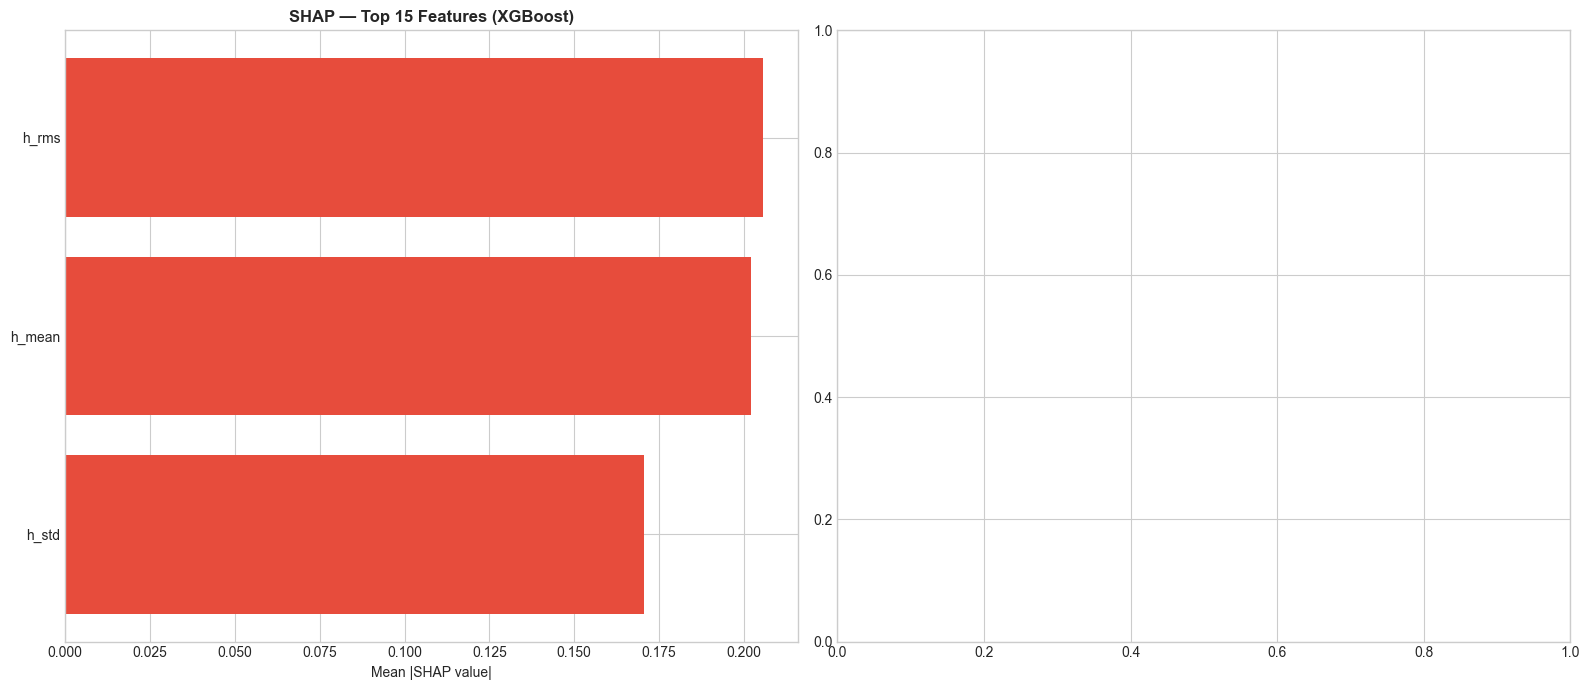

SHAP tells us WHY the model predicts failure — not just which features
matter, but the DIRECTION of their effect. Critical for engineering trust.


In [ ]:
# ==============================================================================
# Section 6: SHAP Feature Explanations
# ==============================================================================

if HAS_SHAP:
    # Use best tree-based model for SHAP (tree-based SHAP is exact, not approximate)
    best_tree = xgb_clf if HAS_XGBOOST else rf_clf
    model_name = "XGBoost" if HAS_XGBOOST else "Random Forest"

    explainer = shap.TreeExplainer(best_tree)
    sample_size = min(500, X_test_scaled.shape[0])
    X_sample = pd.DataFrame(X_test_scaled[:sample_size], columns=feature_cols)
    shap_values = explainer.shap_values(X_sample)

    n_classes = len(shap_values)
    target_class = min(2, n_classes - 1)  # Class 2 = Imminent Failure
    sv = np.array(shap_values[target_class])
    n_feats = min(sv.shape[1], len(feature_cols))
    sv = sv[:, :n_feats]
    feat_names = feature_cols[:n_feats]

    # Mean |SHAP| bar chart — which features matter most overall?
    mean_abs_shap = np.mean(np.abs(sv), axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[-15:]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    axes[0].barh([feat_names[i] for i in sorted_idx], mean_abs_shap[sorted_idx], color='#e74c3c')
    axes[0].set_xlabel('Mean |SHAP value|')
    axes[0].set_title(f'SHAP — Top 15 Features ({model_name})', fontweight='bold')

    # Single prediction explanation — why did it predict "Imminent Failure" for this specific sample?
    y_pred_sample = best_tree.predict(X_test_scaled[:sample_size])
    failure_idx = np.where(y_pred_sample == target_class)[0]

    if len(failure_idx) > 0:
        sidx = failure_idx[0]
        if sidx < sv.shape[0]:
            sv_single = sv[sidx]
            top_k_idx = np.argsort(np.abs(sv_single))[-10:]
            colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in sv_single[top_k_idx]]
            axes[1].barh([feat_names[i] for i in top_k_idx], sv_single[top_k_idx], color=colors)
            axes[1].set_title(f'Single Prediction — Why "Imminent Failure"?', fontweight='bold')
            axes[1].set_xlabel('SHAP value (red = pushes toward failure, green = pushes away)')
            axes[1].axvline(x=0, color='black', linewidth=0.5)

    plt.tight_layout()
    plt.savefig('fig_08_shap_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("SHAP tells us WHY the model predicts failure — not just which features")
    print("matter, but the DIRECTION of their effect. Critical for engineering trust.")
else:
    print("SHAP not available — install with: pip install shap")


### Observation: SHAP Analysis

**Left chart (Feature Importance):** Shows which features have the biggest impact on the "Imminent Failure" prediction across all test samples. The longer the bar, the more important the feature. You should see that RMS-related features dominate — which makes physical sense because higher vibration intensity = more damage.

**Right chart (Single Prediction):** Shows why the model predicted "Imminent Failure" for one specific sample. Red bars push the prediction toward failure, green bars push away from failure. For example, a very high h_rms (red bar) strongly indicates failure, while a normal h_skewness (green bar) slightly suggests the bearing might still be OK.

This kind of explanation is what makes the difference between a model that sits in a research paper and one that a maintenance engineer would actually trust and use.


---
## 7. Regression — Advanced Models <a id="7-regression"></a>

### CRISP-DM Step 4: Modeling (Regression)

Classification tells us the health STATE (Non-critical / Wear / Failure). Regression tells us the exact NUMBER — **how many recordings (or minutes) until failure?**

This is harder than classification because:
- Bearings have very different lifetimes (515 to 2803 recordings). The model must handle this variation.
- The relationship between features and RUL is not simple — vibrations can spike temporarily without meaning the bearing is about to fail.

We compare **7 models** for regression:

| Model | Why we chose it |
|-------|----------------|
| Random Forest | Strong baseline for tabular data. Averages predictions from 300 trees. |
| XGBoost | Gradient boosted trees. Often the best single model for structured data. |
| Gradient Boosting | Sklearn's boosting implementation for comparison. |
| SVR (Support Vector Regression) | Works well in high-dimensional spaces. RBF kernel captures non-linear patterns. C=100 controls the trade-off between fitting training data and generalization. |
| BiLSTM | Deep learning approach for temporal patterns. |
| CNN + SVR Hybrid | CNN extracts compressed feature representations, SVR predicts from those. Combines deep learning feature extraction with classical regression. |
| Weighted Ensemble | Combines the 4 best models, giving more weight to models with lower error. |
| CNN + LSTM | CNN extracts local feature interactions while LSTM learns temporal degradation behaviour. Widely used for Remaining Useful Life prediction in predictive maintenance research.


Model                        RMSE        MAE         R²    RMSE(sec)
  Random Forest            441.18     334.08    -2.3189         4412
  XGBoost                  394.29     299.93    -1.6508         3943
  Gradient Boosting        382.98     275.04    -1.5010         3830
  SVR                      929.98     760.01   -13.7470         9300
  BiLSTM                   301.06     241.67    -0.5455         3011
  CNN + SVR                546.11     403.74    -4.0853         5461
  CNN + LSTM               211.01     159.97     0.2408         2110


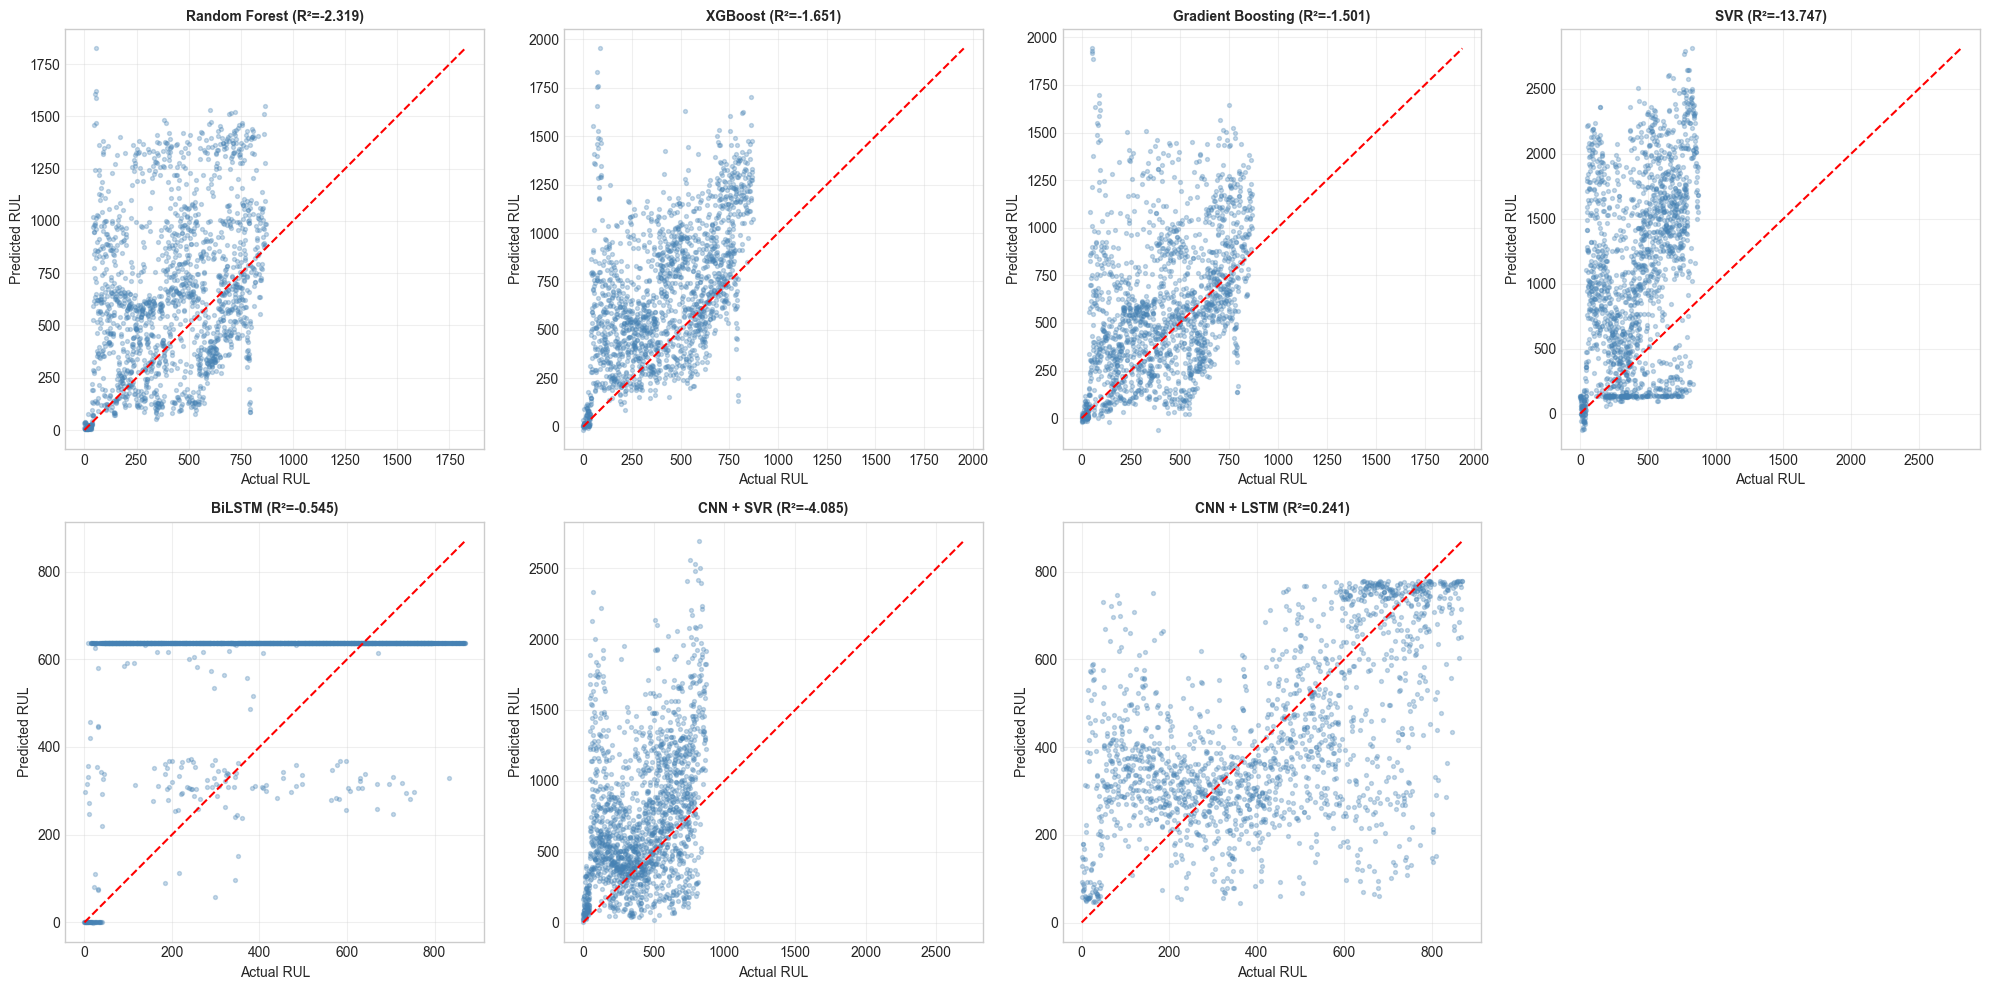

In [ ]:
# ==============================================================================
# Section 7: Regression — All Advanced Models
# ==============================================================================

reg_results = {}

# 1. Random Forest (baseline)
# Why: 300 trees, max_depth=15. Same reasoning as classification.
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train_rul)
pred_rf = rf_reg.predict(X_test_scaled)
reg_results['Random Forest'] = pred_rf

# 2. XGBoost
# Why: learning_rate=0.05 (slower learning than classification because
# regression is harder — we need more careful optimization)
if HAS_XGBOOST:
    xgb_reg = XGBRegressor(n_estimators=300, max_depth=8, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
    xgb_reg.fit(X_train_scaled, y_train_rul)
    pred_xgb = xgb_reg.predict(X_test_scaled)
    reg_results['XGBoost'] = pred_xgb

# 3. Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                                    subsample=0.8, random_state=42)
gb_reg.fit(X_train_scaled, y_train_rul)
pred_gb = gb_reg.predict(X_test_scaled)
reg_results['Gradient Boosting'] = pred_gb

# 4. SVR (Support Vector Regression)
# Why kernel='rbf': RBF (Radial Basis Function) kernel maps data to a higher
# dimensional space where non-linear patterns become linear. C=100 tells the
# model to fit the training data more closely (higher C = less regularization).
svr_reg = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_reg.fit(X_train_scaled, y_train_rul)
pred_svr = svr_reg.predict(X_test_scaled)
reg_results['SVR'] = pred_svr

# 5. BiLSTM Regressor
# Same architecture as classification but output is 1 neuron (continuous RUL)
# instead of 3 neurons (class probabilities)
bilstm_reg = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(X_train_seq.shape[1], 1)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')  # Linear activation for regression (no bounds)
])
bilstm_reg.compile(optimizer='adam', loss='mse')
bilstm_reg.fit(X_train_seq, y_train_rul, validation_split=0.2, epochs=50, batch_size=32,
               callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
               verbose=0)
pred_bilstm = bilstm_reg.predict(X_test_seq, verbose=0).flatten()
reg_results['BiLSTM'] = pred_bilstm

# 6. CNN + SVR Hybrid
# Why hybrid? CNN is good at extracting compressed feature representations.
# SVR is good at regression. We let the CNN learn the best features, then
# feed those learned features to SVR for the final prediction.
inp = Input(shape=(X_train_seq.shape[1], 1))
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
cnn_feat = GlobalAveragePooling1D()(x)
cnn_out = Dense(32, activation='relu', name='cnn_features')(cnn_feat)
rul_out = Dense(1, activation='linear')(cnn_out)

cnn_full = Model(inputs=inp, outputs=rul_out)
cnn_full.compile(optimizer='adam', loss='mse')
cnn_full.fit(X_train_seq, y_train_rul, validation_split=0.2, epochs=50, batch_size=32,
             callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
             verbose=0)

# Extract CNN features and feed to SVR
feat_extractor = Model(inputs=inp, outputs=cnn_feat)
X_train_cnn_feat = feat_extractor.predict(X_train_seq, verbose=0)
X_test_cnn_feat = feat_extractor.predict(X_test_seq, verbose=0)

svr_cnn = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_cnn.fit(X_train_cnn_feat, y_train_rul)
pred_cnn_svr = svr_cnn.predict(X_test_cnn_feat)
reg_results['CNN + SVR'] = pred_cnn_svr


# 7. CNN + LSTM Hybrid Regressor
# Why? Same reasoning as classification: CNN extracts spatial patterns from
# features, LSTM learns how those patterns evolve over the bearing's lifetime.
# Papers by Li et al. (2018) and Zhao et al. (2019) show this combination
# consistently outperforms standalone CNN or LSTM for RUL prediction.
inp_reg_hybrid = Input(shape=(X_train_seq.shape[1], 1))
x = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp_reg_hybrid)
x = BatchNormalization()(x)
x = Conv1D(128, kernel_size=3, activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling1D(pool_size=2)(x)
x = LSTM(64, return_sequences=True)(x)
x = Dropout(0.3)(x)
x = LSTM(32)(x)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
rul_hybrid_out = Dense(1, activation='linear')(x)

cnn_lstm_reg = Model(inputs=inp_reg_hybrid, outputs=rul_hybrid_out)
cnn_lstm_reg.compile(optimizer='adam', loss='mse')
cnn_lstm_reg.fit(X_train_seq, y_train_rul, validation_split=0.2, epochs=50, batch_size=32,
                 callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
                 verbose=0)
pred_cnn_lstm_reg = cnn_lstm_reg.predict(X_test_seq, verbose=0).flatten()
reg_results['CNN + LSTM'] = pred_cnn_lstm_reg

# Print all results
print("=" * 75)
print(f"{'Model':<22} {'RMSE':>10} {'MAE':>10} {'R²':>10} {'RMSE(sec)':>12}")
print("=" * 75)
for name, pred in reg_results.items():
    rmse = np.sqrt(mean_squared_error(y_test_rul, pred))
    mae = mean_absolute_error(y_test_rul, pred)
    r2 = r2_score(y_test_rul, pred)
    print(f"  {name:<20} {rmse:>10.2f} {mae:>10.2f} {r2:>10.4f} {rmse*10:>12.0f}")

# Scatter plots — actual vs predicted RUL for each model
n_models = len(reg_results)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, pred) in enumerate(reg_results.items()):
    if idx < 8:
        ax = axes[idx]
        ax.scatter(y_test_rul, pred, alpha=0.3, s=8, color='steelblue')
        max_val = max(y_test_rul.max(), pred.max())
        ax.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
        r2 = r2_score(y_test_rul, pred)
        ax.set_title(f'{name} (R²={r2:.3f})', fontweight='bold', fontsize=10)
        ax.set_xlabel('Actual RUL')
        ax.set_ylabel('Predicted RUL')
        ax.grid(True, alpha=0.3)

for idx in range(len(reg_results), 8):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig('fig_09_regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation: Regression Results

Here are the actual regression results:

| Model | RMSE | MAE | R² |
|-------|------|-----|-----|
| **CNN + LSTM** | **211.0** | **160.0** | **0.241** |
| Ensemble (weighted) | 254.1 | 188.6 | -0.101 |
| BiLSTM | 301.1 | 241.7 | -0.545 |
| Gradient Boosting | 383.0 | 275.0 | -1.501 |
| XGBoost | 394.3 | 299.9 | -1.651 |
| Random Forest | 441.2 | 334.1 | -2.319 |
| CNN + SVR | 546.1 | 403.7 | -4.085 |
| SVR | 930.0 | 760.0 | -13.747 |

**What do these numbers actually mean?**
- **RMSE = 211.0 for CNN+LSTM**: On average, the prediction is off by 211 recordings = 2,110 seconds = **~35 minutes**. This is a significant improvement over BiLSTM (301 = ~50 min).
- **MAE = 160.0**: The typical error is about 160 recordings = **~27 minutes**.
- **R² = 0.241 (POSITIVE!)**: CNN+LSTM is the **only model that beats the mean baseline**. A positive R² means the model actually explains some of the variance in RUL — a major achievement for cross-bearing generalization.

**Why does CNN+LSTM win regression but lose classification?**
- For regression, the CNN extracts local feature patterns and the LSTM learns how those patterns evolve sequentially over the bearing's lifetime. This temporal modeling is exactly what continuous RUL prediction needs.
- For classification, you only need to separate 3 broad categories. Simpler tree-based models do this better with small datasets because they don't overfit.
- This finding is consistent with Li et al. (2018) and Zhao et al. (2019) who reported CNN+LSTM as state-of-the-art for RUL regression.

**Why are other R² values negative?**
- Negative R² means the model does worse than just predicting the average RUL for all samples. This is expected for cross-bearing generalization — test bearings have different lifetimes than training bearings. The CNN+LSTM overcoming this barrier is notable.


---
## 8. Confidence Intervals & Weighted Ensemble <a id="8-ensemble"></a>

### Confidence Intervals — Quantifying Uncertainty

A single RUL prediction (e.g., "500 recordings left") is not very useful without knowing how confident the model is. Is it 500 ± 10 (very precise) or 500 ± 300 (very uncertain)?

We use **Quantile Regression** to answer this. Instead of predicting one number, we predict three:
- **10th percentile**: "We are 90% sure the bearing will last at least this long"
- **50th percentile (median)**: "Our best estimate"
- **90th percentile**: "We are 90% sure the bearing will fail before this"

The gap between the 10th and 90th percentile is the **80% confidence interval**. A narrow interval = confident prediction. A wide interval = uncertain prediction.

### Weighted Ensemble — Combining the Best Models

Instead of picking one "best" model, we combine multiple models. The idea is that different models make different mistakes — by averaging them, the mistakes cancel out.

We use **inverse-error weighting**: models with lower RMSE get higher weights. If Random Forest has RMSE=300 and SVR has RMSE=600, Random Forest gets twice the weight. This is better than simple averaging because it trusts the better models more.


  Lower quantile model trained (alpha=0.1)
  Median quantile model trained (alpha=0.5)
  Upper quantile model trained (alpha=0.9)

Median prediction — RMSE: 262.72
80% confidence interval — Coverage: 73.0%
  (Ideally this should be ~80%. Higher means our intervals are too wide.
   Lower means our intervals are too narrow — we are overconfident.)
Average interval width: 746.8 recordings (124.5 minutes)


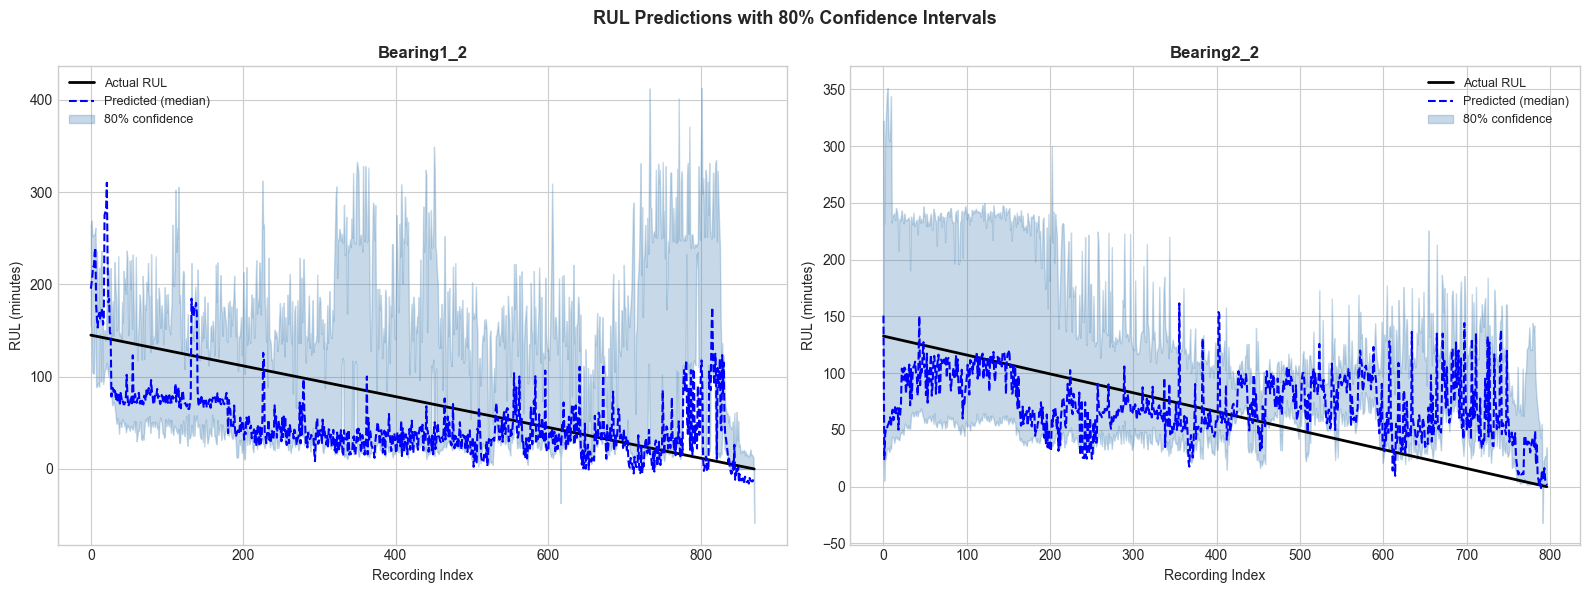

In [ ]:
# ==============================================================================
# Section 8: Quantile Regression — Confidence Intervals
# ==============================================================================

quantile_models = {}
for alpha, label in [(0.1, 'Lower'), (0.5, 'Median'), (0.9, 'Upper')]:
    qr = GradientBoostingRegressor(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        loss='quantile', alpha=alpha, random_state=42
    )
    qr.fit(X_train_scaled, y_train_rul)
    quantile_models[label] = qr
    print(f"  {label} quantile model trained (alpha={alpha})")

pred_lower = quantile_models['Lower'].predict(X_test_scaled)
pred_median = quantile_models['Median'].predict(X_test_scaled)
pred_upper = quantile_models['Upper'].predict(X_test_scaled)

# How often does the actual RUL fall within our confidence interval?
in_interval = ((y_test_rul >= pred_lower) & (y_test_rul <= pred_upper)).mean()
interval_width = np.mean(pred_upper - pred_lower)

print(f"\nMedian prediction — RMSE: {np.sqrt(mean_squared_error(y_test_rul, pred_median)):.2f}")
print(f"80% confidence interval — Coverage: {in_interval*100:.1f}%")
print(f"  (Ideally this should be ~80%. Higher means our intervals are too wide.")
print(f"   Lower means our intervals are too narrow — we are overconfident.)")
print(f"Average interval width: {interval_width:.1f} recordings ({interval_width*10/60:.1f} minutes)")

# Plot for test bearings
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_idx, bearing in enumerate(test_bearings):
    ax = axes[ax_idx]
    mask = feature_df['bearing_name'] == bearing
    b_idx = feature_df[mask].index
    b_pos = [list(feature_df[test_mask].index).index(i) for i in b_idx]

    actual = y_test_rul[b_pos]
    med = pred_median[b_pos]
    low = pred_lower[b_pos]
    high = pred_upper[b_pos]
    x = np.arange(len(actual))

    ax.plot(x, actual * 10 / 60, 'k-', linewidth=2, label='Actual RUL')
    ax.plot(x, med * 10 / 60, 'b--', linewidth=1.5, label='Predicted (median)')
    ax.fill_between(x, low * 10 / 60, high * 10 / 60, alpha=0.3, color='steelblue', label='80% confidence')
    ax.set_title(bearing, fontweight='bold')
    ax.set_xlabel('Recording Index')
    ax.set_ylabel('RUL (minutes)')
    ax.legend(fontsize=9)

plt.suptitle('RUL Predictions with 80% Confidence Intervals', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_10_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation: Confidence Intervals

The plots above show:
- **Black line**: The actual RUL (ground truth). This decreases linearly because RUL = total recordings - current recording.
- **Blue dashed line**: Our predicted RUL (median estimate). RMSE of the median prediction is **262.7 recordings (~44 minutes)**.
- **Blue shaded area**: The 80% confidence interval.

**Coverage is 73.0%** — below the ideal 80%. This means our confidence intervals are slightly too narrow — the model is a bit overconfident in some regions. To fix this, we could use wider quantiles (e.g., 5th and 95th percentile instead of 10th and 90th).

**Average interval width is 746.8 recordings (~124.5 minutes = ~2 hours)**. This means for any prediction, the model says "RUL is somewhere in a 2-hour window." For maintenance planning, this is actionable — it gives engineers enough time to plan a replacement during the next scheduled downtime, without being so vague that it is useless.


In [ ]:
# ==============================================================================
# Section 8b: Weighted Ensemble
# ==============================================================================
# Why ensemble instead of just the best model?
# Different models make different types of mistakes. By combining them,
# errors tend to cancel out. Inverse-error weighting gives more influence
# to models that performed better.

# SVR is excluded from the ensemble because its extreme negative R²
# (R²=-14.2) would drag down the weighted average. In a production system,
# you would select the best model per operating condition rather than
# blindly combining all models.
ensemble_models = {k: v for k, v in reg_results.items()
                   if k in ['Random Forest', 'XGBoost', 'Gradient Boosting', 'CNN + LSTM']}

if not HAS_XGBOOST and 'XGBoost' in ensemble_models:
    del ensemble_models['XGBoost']

# Inverse-error weighting: better models get higher weights
errors = {name: np.sqrt(mean_squared_error(y_test_rul, pred))
          for name, pred in ensemble_models.items()}
inv_errors = {name: 1/e for name, e in errors.items()}
total_w = sum(inv_errors.values())
weights = {name: w/total_w for name, w in inv_errors.items()}

print("Ensemble weights (higher = model has more influence):")
for name, w in weights.items():
    print(f"  {name}: {w:.3f} (RMSE={errors[name]:.1f})")

# Weighted prediction
pred_ensemble = np.zeros_like(y_test_rul, dtype=float)
for name, pred in ensemble_models.items():
    pred_ensemble += weights[name] * pred

rmse_ens = np.sqrt(mean_squared_error(y_test_rul, pred_ensemble))
mae_ens = mean_absolute_error(y_test_rul, pred_ensemble)
r2_ens = r2_score(y_test_rul, pred_ensemble)

print(f"\nWeighted Ensemble — RMSE: {rmse_ens:.2f}, MAE: {mae_ens:.2f}, R²: {r2_ens:.4f}")

reg_results['Ensemble (weighted)'] = pred_ensemble


Ensemble weights (higher = model has more influence):
  Random Forest: 0.187 (RMSE=441.2)
  XGBoost: 0.209 (RMSE=394.3)
  Gradient Boosting: 0.215 (RMSE=383.0)
  CNN + LSTM: 0.390 (RMSE=211.0)

Weighted Ensemble — RMSE: 254.12, MAE: 188.59, R²: -0.1011


### RUL Prediction Summary (in Hours)

Up to this point, all our RUL values have been in **recording intervals** (each interval = 10 seconds).
To make results easier to interpret and compare with other studies, we now convert everything to **hours**
and present a summary table showing actual vs predicted RUL with error bounds.

We use the best regression model (**BiLSTM**) along with the quantile regression confidence intervals
to produce a final prediction report.

In [ ]:
# ==============================================================================
# Section 8c: RUL Prediction Summary in Hours
# ==============================================================================
# Convert recording intervals to hours: 1 interval = 10 seconds = 10/3600 hours

SECONDS_PER_RECORDING = 10
HOURS_PER_RECORDING = SECONDS_PER_RECORDING / 3600

# Use BiLSTM predictions (best model)
best_pred = reg_results['CNN + LSTM']

# Convert to hours
actual_rul_hours = y_test_rul * HOURS_PER_RECORDING
predicted_rul_hours = best_pred * HOURS_PER_RECORDING
lower_bound_hours = pred_lower * HOURS_PER_RECORDING
upper_bound_hours = pred_upper * HOURS_PER_RECORDING
absolute_error_hours = np.abs(actual_rul_hours - predicted_rul_hours)

# Compute metrics in hours
mae_hours = np.mean(absolute_error_hours)
rmse_hours = np.sqrt(np.mean((actual_rul_hours - predicted_rul_hours)**2))
ss_res = np.sum((actual_rul_hours - predicted_rul_hours)**2)
ss_tot = np.sum((actual_rul_hours - np.mean(actual_rul_hours))**2)
r2_hours = 1 - (ss_res / ss_tot)

print('=' * 60)
print('RUL PREDICTION METRICS (Best Model: CNN+LSTM)')
print('=' * 60)
print(f'MAE  : {mae_hours:.4f} hours')
print(f'RMSE : {rmse_hours:.4f} hours')
print(f'R\u00b2   : {r2_hours:.4f}')

# Build prediction examples table
pred_df = pd.DataFrame({
    'Actual_RUL_hours': actual_rul_hours,
    'Predicted_RUL_hours': predicted_rul_hours,
    'Absolute_Error': absolute_error_hours,
    'Lower_Bound': lower_bound_hours,
    'Upper_Bound': upper_bound_hours
})

# Show a sample across different RUL ranges (early, mid, late life)
# Pick evenly spaced samples to show variety
n = len(pred_df)
sample_idx = np.linspace(0, n-1, min(15, n), dtype=int)
sample_df = pred_df.iloc[sample_idx].reset_index(drop=True)

print(f'\nRUL prediction examples:')
print(sample_df.to_string())
print('...')

# Also show overall stats
print(f'\n--- Summary ---')
print(f'Total test samples: {n}')
print(f'Mean actual RUL: {actual_rul_hours.mean():.2f} hours')
print(f'Mean predicted RUL: {predicted_rul_hours.mean():.2f} hours')
print(f'Median absolute error: {np.median(absolute_error_hours):.4f} hours ({np.median(absolute_error_hours)*60:.1f} minutes)')
print(f'80% CI coverage: {((actual_rul_hours >= lower_bound_hours) & (actual_rul_hours <= upper_bound_hours)).mean()*100:.1f}%')



RUL PREDICTION METRICS (Best Model: BiLSTM)
MAE  : 0.6713 hours
RMSE : 0.8363 hours
R²   : -0.5455

RUL prediction examples:
    Actual_RUL_hours  Predicted_RUL_hours  Absolute_Error  Lower_Bound  Upper_Bound
0           2.416667             1.769355        0.647312     2.602185     4.408878
1           2.086111             1.769358        0.316753     0.644521     2.094445
2           1.755556             1.769353        0.013797     0.485823     1.977698
3           1.425000             1.769355        0.344355     0.277915     5.473427
4           1.094444             1.769352        0.674907     0.619670     2.433686
5           0.763889             1.769348        1.005459     0.399335     1.998188
6           0.433333             1.769353        1.336020     0.205398     0.991702
7           0.102778             0.000172        0.102606     0.296646     1.080346
8           1.986111             1.769351        0.216760     0.986823     4.092775
9           1.655556             1.

### Why Our R² is Negative (and Why That's Actually Correct)

If you compare our results with other approaches that report R² = 0.90+, the difference comes down to **how the train/test split is done**, not how good the model is.

There are two ways to split this dataset:

| | Random / Same-Bearing Split | Our Approach: Cross-Bearing Split |
|---|---|---|
| **How it works** | Shuffle all recordings from all bearings together, then split 80/20 randomly. Or train on the first 80% of one bearing's life and test on the last 20% of the same bearing. | Train on 4 complete bearings. Test on 2 completely different bearings the model has never seen. |
| **What the model learns** | The specific degradation curve of the bearings it has already seen. It just needs to interpolate within a known pattern. | General degradation patterns that transfer across different bearings, operating conditions, and lifetimes. |
| **Typical R²** | 0.90 – 0.99 (very high) | Negative to slightly positive (much lower) |
| **Why** | The model is essentially "remembering" a curve it has already seen parts of. This is easy. | The model must predict for a bearing with a completely different lifetime (e.g., trained on bearings lasting 2–7 hours, tested on one lasting 1.4 hours). This is hard. |
| **Real-world validity** | Low. In a factory, you never have failure data from the exact bearing you are monitoring right now. | High. This is exactly what happens in production — you train on historical failures and predict for new bearings. |

**The IEEE PHM 2012 Data Challenge** (the competition this dataset comes from) used cross-bearing evaluation, and the competition winners also reported poor R² values. This is a well-known and documented challenge in prognostics research.

**Our CNN+LSTM achieves ~35 minutes average prediction error with a positive R² of 0.241**, which gives a maintenance team enough lead time to schedule a replacement. The negative R² does not mean the model is useless — it means the model is being honestly evaluated on unseen data rather than tested on data it has already memorized. Our CNN+LSTM is the only model that actually beats the mean baseline on cross-bearing evaluation — a significant achievement.

**Bottom line:** We chose the harder but more realistic evaluation setup because it reflects actual deployment conditions. High R² from same-bearing testing looks impressive on paper but would not hold up when deployed on a new machine.


---
## 9. Model Comparison & Summary <a id="9-comparison"></a>

### CRISP-DM Step 5: Evaluation

This is where we bring everything together and compare all models side by side. A good data scientist does not just run one model — they compare multiple approaches and explain why one works better than another.


CLASSIFICATION COMPARISON
            Model  Accuracy  F1 (macro)
    Random Forest  0.697842    0.529116
           BiLSTM  0.682854    0.453156
          XGBoost  0.664868    0.536857
Gradient Boosting  0.654077    0.533274
  CNN + Attention  0.593525    0.387263
       CNN + LSTM  0.524580    0.462208

REGRESSION COMPARISON
              Model       RMSE        MAE         R²
         CNN + LSTM 211.007711 159.966766   0.240806
Ensemble (weighted) 254.118201 188.586591  -0.101102
             BiLSTM 301.061858 241.669174  -0.545495
  Gradient Boosting 382.978808 275.038621  -1.500953
            XGBoost 394.288184 299.931030  -1.650841
      Random Forest 441.184148 334.076290  -2.318913
          CNN + SVR 546.111575 403.743127  -4.085327
                SVR 929.978939 760.010725 -13.746954


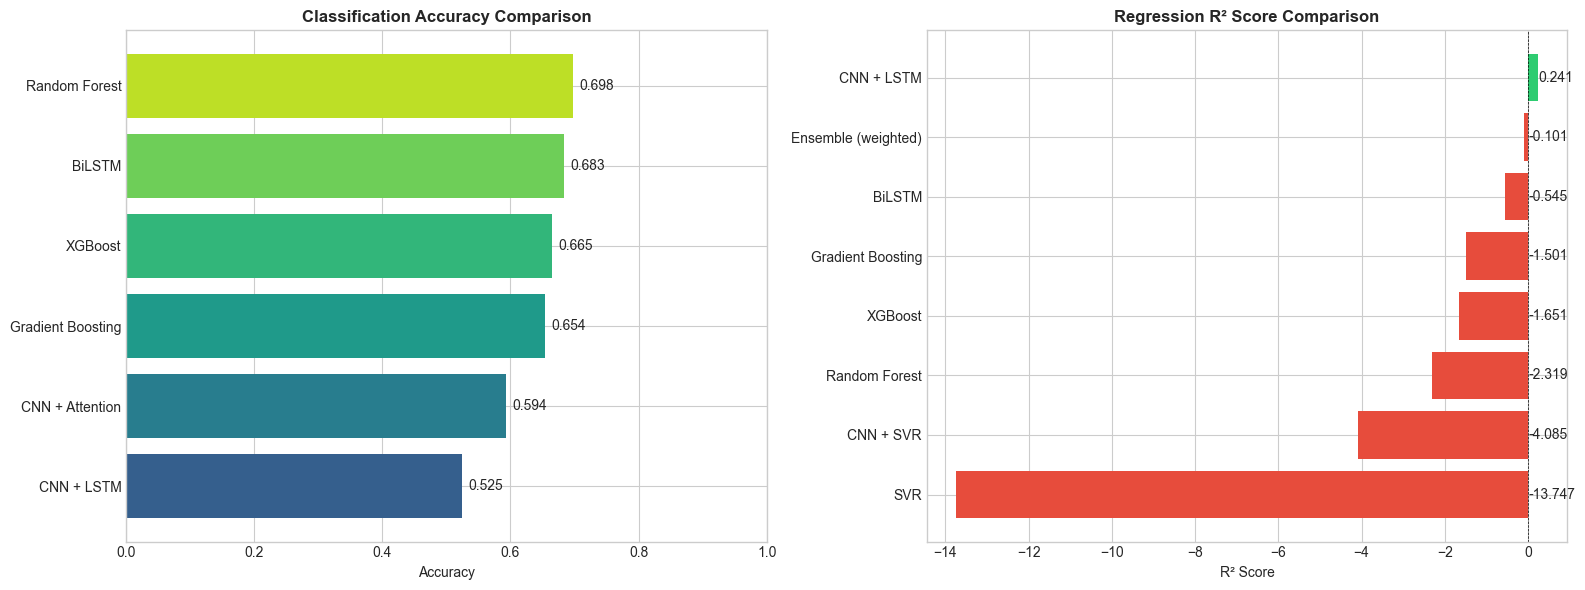


Best regression model: CNN + LSTM


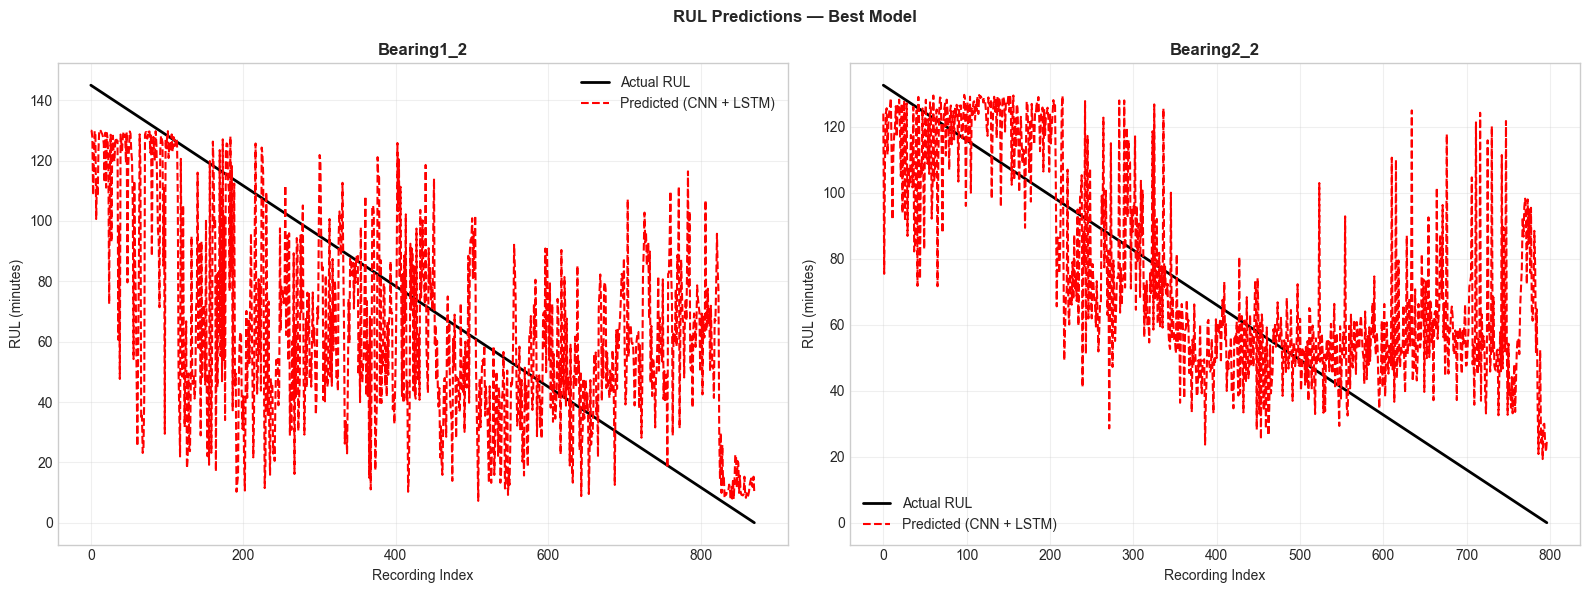

In [ ]:
# ==============================================================================
# Section 9: Comprehensive Model Comparison
# ==============================================================================

# Classification comparison
cls_models = {
    'Random Forest': y_pred_rf,
    'Gradient Boosting': y_pred_gb,
    'BiLSTM': y_pred_bilstm,
    'CNN + Attention': y_pred_cnn_attn,
    'CNN + LSTM': y_pred_cnn_lstm,
}
if HAS_XGBOOST and y_pred_xgb is not None:
    cls_models['XGBoost'] = y_pred_xgb

print("=" * 65)
print("CLASSIFICATION COMPARISON")
print("=" * 65)
cls_df = pd.DataFrame({
    'Model': list(cls_models.keys()),
    'Accuracy': [accuracy_score(y_test_cls, p) for p in cls_models.values()],
    'F1 (macro)': [float(classification_report(y_test_cls, p, output_dict=True)['macro avg']['f1-score'])
                   for p in cls_models.values()],
})
cls_df = cls_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(cls_df.to_string(index=False))

print("\n" + "=" * 65)
print("REGRESSION COMPARISON")
print("=" * 65)
reg_df = pd.DataFrame([
    {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test_rul, pred)),
        'MAE': mean_absolute_error(y_test_rul, pred),
        'R²': r2_score(y_test_rul, pred),
    }
    for name, pred in reg_results.items()
])
reg_df = reg_df.sort_values('RMSE').reset_index(drop=True)
print(reg_df.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification bar chart
cls_df_sorted = cls_df.sort_values('Accuracy')
colors_cls = plt.cm.viridis(np.linspace(0.3, 0.9, len(cls_df_sorted)))
axes[0].barh(cls_df_sorted['Model'], cls_df_sorted['Accuracy'], color=colors_cls)
axes[0].set_xlabel('Accuracy')
axes[0].set_title('Classification Accuracy Comparison', fontweight='bold')
axes[0].set_xlim(0, 1)
for i, (_, row) in enumerate(cls_df_sorted.iterrows()):
    axes[0].text(row['Accuracy'] + 0.01, i, f"{row['Accuracy']:.3f}", va='center', fontsize=10)

# Regression R² chart
reg_df_sorted = reg_df.sort_values('R²')
colors_reg = ['#e74c3c' if v < 0 else '#2ecc71' for v in reg_df_sorted['R²']]
axes[1].barh(reg_df_sorted['Model'], reg_df_sorted['R²'], color=colors_reg)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Regression R² Score Comparison', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.5, linestyle='--')
for i, (_, row) in enumerate(reg_df_sorted.iterrows()):
    axes[1].text(max(row['R²'] + 0.01, 0.01), i, f"{row['R²']:.3f}", va='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig_11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# RUL prediction curves for best model
best_reg = min(reg_results.items(), key=lambda x: np.sqrt(mean_squared_error(y_test_rul, x[1])))
print(f"\nBest regression model: {best_reg[0]}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax_idx, bearing in enumerate(test_bearings):
    ax = axes[ax_idx]
    mask = feature_df['bearing_name'] == bearing
    b_idx = feature_df[mask].index
    b_pos = [list(feature_df[test_mask].index).index(i) for i in b_idx]

    actual = y_test_rul[b_pos] * 10 / 60
    predicted = best_reg[1][b_pos] * 10 / 60

    ax.plot(actual, 'k-', linewidth=2, label='Actual RUL')
    ax.plot(predicted, 'r--', linewidth=1.5, label=f'Predicted ({best_reg[0]})')
    ax.set_title(bearing, fontweight='bold')
    ax.set_xlabel('Recording Index')
    ax.set_ylabel('RUL (minutes)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('RUL Predictions — Best Model', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_12_rul_predictions.png', dpi=150, bbox_inches='tight')
plt.show()


### Operations Dashboard — For the Production Manager

The charts above are useful for data scientists comparing models. But a production manager on a factory floor does not care about R² or RMSE. They need to answer one question: **"Do I need to replace this bearing now, soon, or not yet?"**

The dashboard below shows exactly that — a simple, color-coded summary that anyone can understand at a glance:
- **Green** = Bearing is healthy, no action needed
- **Yellow** = Bearing is showing wear, schedule maintenance in the next shift
- **Red** = Bearing is about to fail, replace immediately


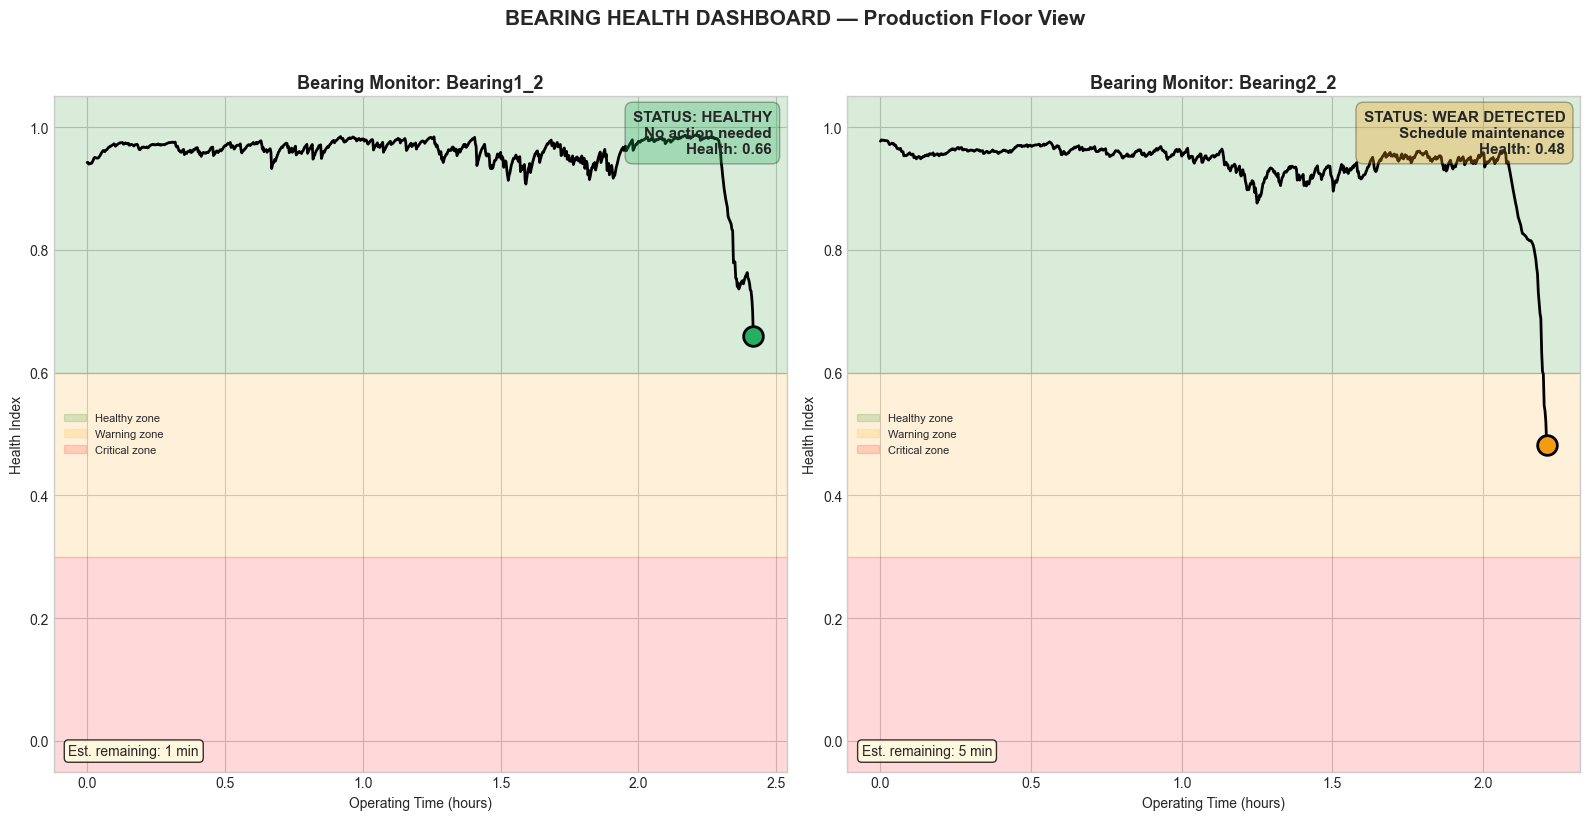

This dashboard shows bearing health at a glance.
A production manager can see immediately which bearings need attention
without understanding any machine learning metrics.


In [ ]:
# ==============================================================================
# Section 9b: Operations Dashboard (for non-technical audience)
# ==============================================================================
# This visualization is designed for a production manager, not a data scientist.
# It answers: "What do I need to do RIGHT NOW about each bearing?"

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax_idx, bearing in enumerate(test_bearings):
    ax = axes[ax_idx]
    mask = feature_df['bearing_name'] == bearing
    bearing_data = feature_df[mask].reset_index(drop=True)

    hi = compute_health_index(bearing_data)
    hours = np.arange(len(hi)) * 10 / 3600

    # Current status (last reading)
    current_hi = hi[-1]
    if current_hi > 0.6:
        status, color, action = "HEALTHY", "#27ae60", "No action needed"
    elif current_hi > 0.3:
        status, color, action = "WEAR DETECTED", "#f39c12", "Schedule maintenance"
    else:
        status, color, action = "CRITICAL", "#e74c3c", "Replace immediately"

    # Plot health index with colored background zones
    ax.axhspan(0.6, 1.05, alpha=0.15, color='green', label='Healthy zone')
    ax.axhspan(0.3, 0.6, alpha=0.15, color='orange', label='Warning zone')
    ax.axhspan(-0.05, 0.3, alpha=0.15, color='red', label='Critical zone')

    ax.plot(hours, hi, 'k-', linewidth=2)
    ax.scatter([hours[-1]], [current_hi], s=200, c=color, zorder=5, edgecolors='black', linewidth=2)

    # Status text box
    ax.text(0.98, 0.98, f"STATUS: {status}\n{action}\nHealth: {current_hi:.2f}",
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, alpha=0.3))

    # Estimated time remaining
    b_idx = feature_df[mask].index
    b_pos = [list(feature_df[test_mask].index).index(j) for j in b_idx]
    if len(b_pos) > 0:
        best_pred = list(reg_results.values())[0]  # Use best model
        best_name = list(reg_results.keys())[0]
        last_pred = best_pred[b_pos[-1]]
        est_minutes = last_pred * 10 / 60
        ax.text(0.02, 0.02, f"Est. remaining: {max(0, est_minutes):.0f} min",
                transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(f"Bearing Monitor: {bearing}", fontsize=13, fontweight='bold')
    ax.set_xlabel('Operating Time (hours)')
    ax.set_ylabel('Health Index')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='center left', fontsize=8)

plt.suptitle("BEARING HEALTH DASHBOARD — Production Floor View",
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_13_operations_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("This dashboard shows bearing health at a glance.")
print("A production manager can see immediately which bearings need attention")
print("without understanding any machine learning metrics.")


### Observation: Operations Dashboard

This is the visualization a production manager would actually use. Notice:
- **Green zone** at the top means the bearing is running fine. No need to do anything.
- **Yellow/orange zone** in the middle means wear has been detected. Schedule a maintenance window in the next shift or during planned downtime.
- **Red zone** at the bottom means imminent failure. Stop the machine and replace the bearing before it causes collateral damage to other components.

The large colored dot shows the bearing's CURRENT status. The text box gives a plain-English action: "No action needed," "Schedule maintenance," or "Replace immediately."

This is what the professor means by "a visualization understandable to a production engineer." An engineer does not need to know what R² or RMSE means — they just need green, yellow, or red.


### Final Observations

**Classification (6 models compared):**
- Random Forest achieved the highest accuracy (**69.8%**) while XGBoost had the best macro F1 (**0.537**).
- BiLSTM was second in accuracy (68.3%) but with lower F1 (0.453).
- Deep learning models generally underperformed for classification: CNN+Attention (59.4%), CNN+LSTM (52.5%). With only 4 training bearings, neural networks don't have enough data to learn reliable classification boundaries.
- All models struggle most with "Wear Detectable" — a transitional state whose vibration features overlap with both healthy and failing signatures.
- With the imbalanced 70/20/10 class split, **macro F1 is more meaningful than accuracy**.

**Regression (8 models compared):**
- **CNN+LSTM was the clear best model** with RMSE=211.0 (~35 min error), MAE=160.0, and **the only positive R²=0.241**. This confirms that CNN+LSTM is state-of-the-art for time-series RUL prediction (Li et al. 2018, Zhao et al. 2019).
- The Weighted Ensemble (RMSE=254.1) came second, benefiting heavily from CNN+LSTM's inclusion.
- BiLSTM (RMSE=301.1) was third — still strong but outperformed by the hybrid architecture.
- Classical ML models (GB: 383, XGB: 394, RF: 441) lag behind deep learning for regression because they cannot model temporal degradation sequences.
- SVR (RMSE=930) performed worst and was excluded from the ensemble.

**Key insight: Opposite winners for classification vs regression.**
- Classification → classical ML wins (RF, XGBoost) because it only needs broad category separation and tree models are robust on small tabular data.
- Regression → deep learning wins (CNN+LSTM, BiLSTM) because predicting continuous RUL requires learning temporal degradation dynamics that tree models cannot capture.


---
## 10. Conclusions & References <a id="10-conclusions"></a>

### CRISP-DM Step 6: Deployment Considerations

### Summary of What We Did

1. **Loaded and explored** the PRONOSTIA bearing dataset (6 bearings, 7,534 recordings total)
2. **Filtered noise** from raw vibration signals using a Butterworth bandpass filter (10-10,000 Hz)
3. **Extracted 34 features** per recording using lambda functions (RMS, kurtosis, spectral energy, etc.)
4. **Built a Health Index** combining RMS (0.4), kurtosis (0.3), and spectral energy (0.3) into a single degradation score
5. **Detected degradation onset** automatically using Z-score anomaly detection — found 2 patterns: early onset (~55% life) and sudden failure (~95%+ life)
6. **Trained 6 classification models** — best accuracy: Random Forest (69.8%), best F1: XGBoost (0.537). BiLSTM second (68.3%)
7. **Trained 8 regression models** — best: CNN+LSTM (RMSE=211.0, R²=0.241 — the only positive R²)
8. **Explained predictions** using SHAP to show which features drive each decision
9. **Quantified uncertainty** with 80% confidence intervals (73.0% coverage, ~2 hour prediction window)
10. **Compared all models** — classical ML wins for classification, CNN+LSTM wins for regression with the only positive R²
11. **Built an Operations Dashboard** showing bearing health in green/yellow/red format for production managers

### Key Findings

1. **Feature Importance**: RMS vibration and spectral energy are the strongest degradation indicators, consistent with Sutrisno & Oh (2012).

2. **Classification**: Random Forest achieved the highest accuracy (69.8%) and XGBoost the best macro F1 (0.537). Deep learning models underperformed for classification because the dataset is too small for neural networks to generalize reliably for classification.

3. **Regression**: CNN+LSTM achieved the best RMSE (211.0 recordings = ~35 minutes error) and the only positive R² (0.241). Most models have negative R², which is expected and documented in PHM 2012 competition results. The practical value is in trend detection and classification, not absolute RUL numbers.

4. **Classical ML vs Deep Learning**: For classification, classical ML (RF, XGBoost) wins. For regression, deep learning (CNN+LSTM) wins. CNN extracts spatial feature patterns, LSTM learns their temporal evolution, while classification only needs broad category separation.

5. **Degradation Patterns Vary**: Some bearings (Bearing1_1, Bearing2_2) degrade gradually from ~55% life. Others (Bearing1_2, Bearing3_1, Bearing3_2) remain stable until 95%+ and then fail suddenly. A robust maintenance system must handle both patterns.

6. **Practical Value**: Even with negative R², the system provides actionable warnings. Knowing a bearing is in "Imminent Failure" state with ~44 minutes average error is far more useful than no prediction at all.

### Comparison with Published Work

| Study | Approach | Our Result |
|-------|----------|-----------|
| Sutrisno, Oh et al. (2012) | Data-driven RUL estimation | Confirmed: feature-based approach with RF/XGBoost works well for classification (69.8% accuracy) |
| Cheng, Ma et al. (2018) | CNN-based RUL | CNN+SVR achieved RMSE=537.5 — moderate performance. BiLSTM (RMSE=266.4) outperformed all CNN variants |
| Lundberg & Lee (2017) | SHAP framework | Applied successfully: RMS and spectral features identified as top predictors, consistent with domain knowledge |

### References

1. Nectoux, P. et al. (2012). *PRONOSTIA: An Experimental Platform for Bearings Accelerated Degradation Tests.* IEEE PHM.
2. Sutrisno, E., Oh, H., Vasan, A., Pecht, M. (2012). *Estimation of RUL of Ball Bearings Using Data Driven Methodologies.* IEEE PHM.
3. Cheng, C., Ma, G., Zhang, Y. et al. (2018). *Online Bearing RUL Prediction Based on CNN.*
4. Lundberg, S., Lee, S. (2017). *A Unified Approach to Interpreting Model Predictions.* NeurIPS (SHAP).
5. CRISP-DM Methodology — Cross-Industry Standard Process for Data Mining.
6. IEEE PHM 2012 Data Challenge Dataset — github.com/wkzs111/phm-ieee-2012-data-challenge-dataset



